In [1]:
import warnings
import sys
import os
sys.path.append(os.path.abspath("path"))
warnings.filterwarnings('ignore')
from pm4py.analysis import check_is_workflow_net, check_soundness
from fedap_utils import *
from pm4py.algo.discovery.alpha.variants.plus import apply_aggr

### Preprocessing (EL Filtering) PRO-ACT Dataset

In [2]:
pa_el, pa_df = load_convert_el(el_path=r"./data/proact.csv", case_id='ID', activity_key='Event', timestamp_key='Date')
print(pa_df['Event'].unique())
list_events = ['Onset', 'Start_trial', 'M_0000', 'Censored','M_0100', 'Dead', 'M_1000',
 'M_1010', 'M_1001', 'M_0001', 'M_0110', 'M_1100', 'M_0010',
 'M_0101', 'M_0011']
pa_df_filt = pa_df[pa_df['Event'].isin(list_events)]

threshold=100
event_count = pa_df_filt['Event'].value_counts()
pa_df_filt = pa_df_filt[pa_df_filt['Event'].isin(event_count[event_count >= threshold].index)]
pa_df_filt.to_csv('./data/pa_df_filtered.csv', index=False)

['Onset' 'Start_trial' 'M_0000' 'Censored' 'M_0100' 'Dead' 'M_1000'
 'M_1010' 'M_1110' 'M_1001' 'M_1111' 'M_0110' 'M_0001' 'M_1011' 'M_1100'
 'M_0101' 'M_0010' 'M_1101' 'M_0111' 'M_0011']


# RWD Testing

### ELs Splitting

In [3]:
import numpy as np

id_list = pa_df_filt['ID'].unique()

random_seed = 42 # For reproducibility
np.random.seed(random_seed)
np.random.shuffle(id_list)

num_of_splits = 10
id_groups = np.array_split(id_list, num_of_splits)

df_path_list = []
for i, id_split in enumerate(id_groups):
	splitted = pa_df_filt[pa_df_filt['ID'].isin(id_split)]
	path = f"./data/proact_split{i}.csv"
	df_path_list.append(path)
	splitted.to_csv(path_or_buf=path, index=False)

event_log_tot, df_tot = load_convert_el(el_path=r"./data/pa_df_filtered.csv", case_id='ID', activity_key='Event', timestamp_key='Date')
el_splits = []
for path_split in df_path_list:
	el_split, _ = load_convert_el(el_path=path_split, case_id='ID', activity_key='Event', timestamp_key='Date')
	el_splits.append(el_split)

### AA+ on the entire event log


Entire Event Log (Alpha+):
1-length-loop free net soundness: False


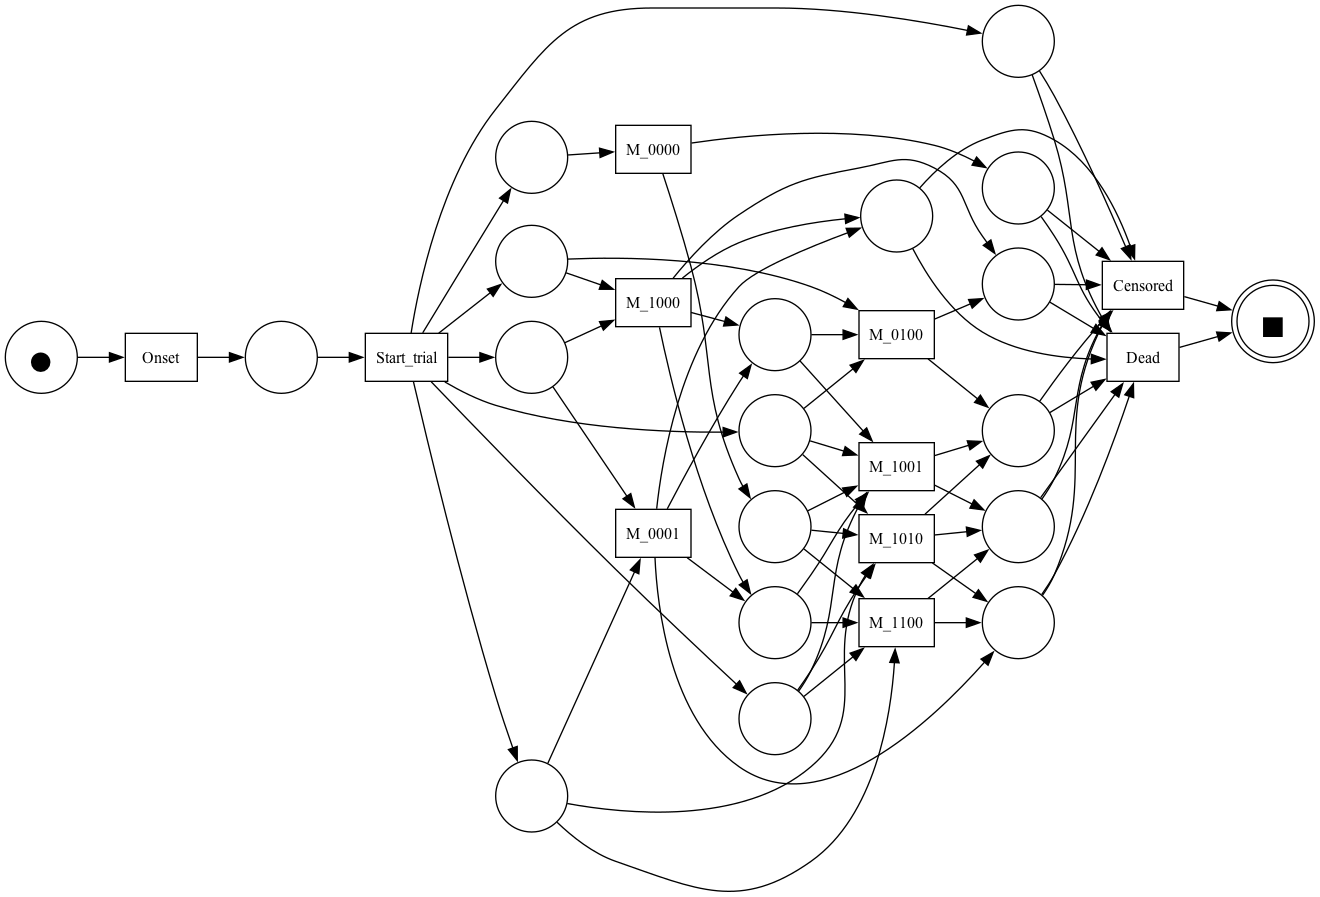

Relations:
 causal
	artificial_start
		{'Onset'}
	Onset
		{'Start_trial'}
	Start_trial
		{'M_0000', 'M_1001', 'M_1010', 'M_0100', 'Dead', 'M_1000', 'M_0001', 'M_1100', 'Censored'}
	M_0000
		{'M_1010', 'M_1001', 'Dead', 'M_1100', 'Censored'}
	M_1000
		{'Dead', 'Censored', 'M_1100', 'M_1001'}
	Censored
		{'artificial_end'}
	M_1001
		{'Dead', 'Censored'}
	Dead
		{'artificial_end'}
	M_1100
		{'Censored', 'Dead'}
	M_0100
		{'Censored', 'Dead'}
	M_0001
		{'Dead', 'Censored', 'M_1001', 'M_0100'}
	M_1010
		{'Dead', 'Censored'}
parallel
	M_0000
		{'M_0001', 'M_1000', 'M_0100'}
	M_1000
		{'M_0000', 'M_1010'}
	M_1100
		{'M_0100'}
	M_0100
		{'M_0000', 'M_1100'}
	M_0001
		{'M_0000'}
	M_1010
		{'M_1000'}
follows
	artificial_start
		{'Onset'}
	Onset
		{'Start_trial'}
	Start_trial
		{'M_0000', 'M_1010', 'M_0100', 'M_1001', 'Dead', 'M_1000', 'M_0001', 'M_1100', 'Censored'}
	M_0000
		{'M_1001', 'M_0100', 'M_1010', 'Dead', 'M_1000', 'M_0001', 'M_1100', 'Censored'}
	M_1000
		{'M_0000', 'M_1001', 'M_1010',

In [4]:
print('\nEntire Event Log (Alpha+):')
net_tot, initial_marking_tot, final_marking_tot, footprint_matrix_tot, loop_one_list_tot, oneL_inputs_tot, oneL_outputs_tot = apply_monocentric(event_log_tot)

Soundness Check Using Inductive Miner

Input is ok.
Petri Net is a workflow net.
Every place is covered by s-components.
There are no dead tasks.
All tasks are live.
Soundness Check using Inductive Miner True


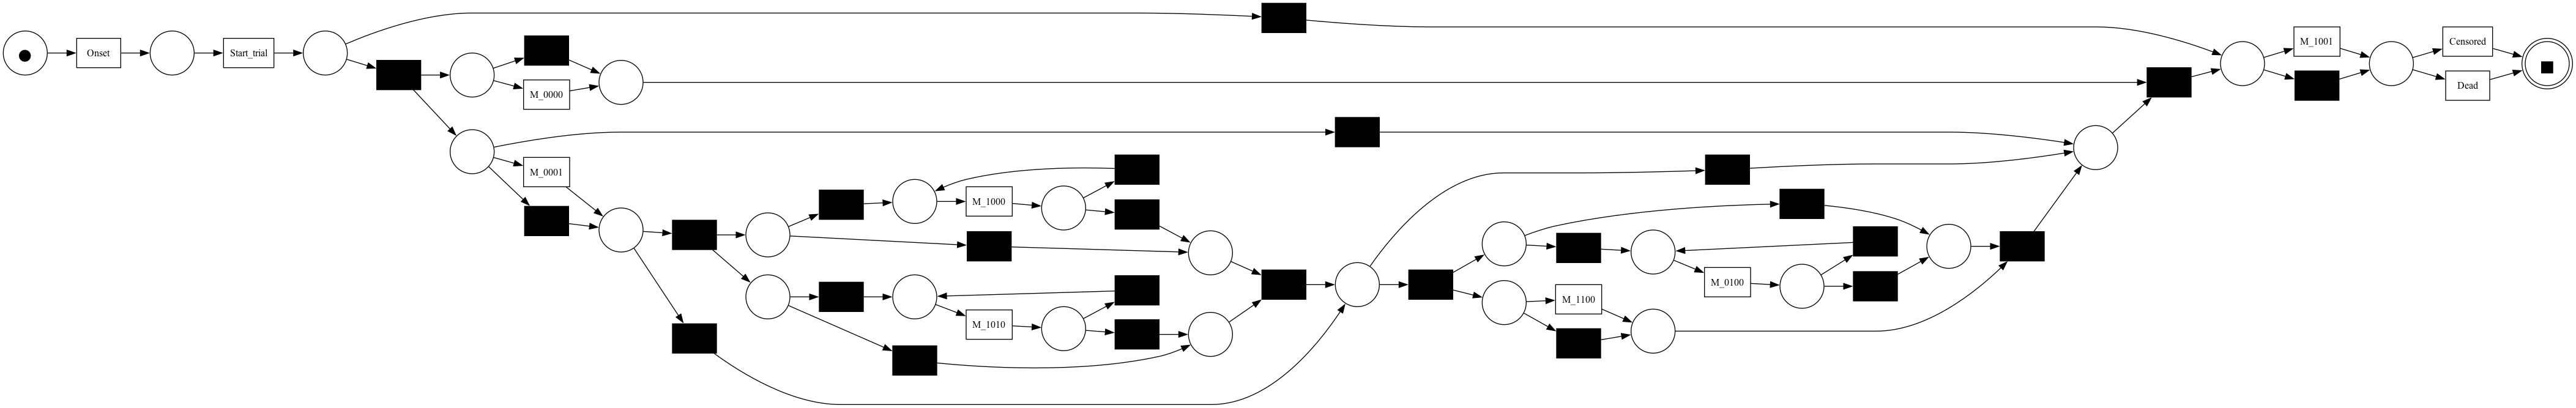

In [5]:
net_ind, initial_marking_ind, final_marking_ind = pm4py.discover_petri_net_inductive(event_log_tot)
sound_check_ind, _ = check_soundness(net_ind, initial_marking_ind, final_marking_ind, print_diagnostics=True)
print(f'Soundness Check using Inductive Miner {sound_check_ind}')
pm4py.view_petri_net(net_ind, initial_marking_ind, final_marking_ind)


## Processing

### Distributed Local processing
FMs are computed independently over different event log splits

1-length-loop free net soundness: False


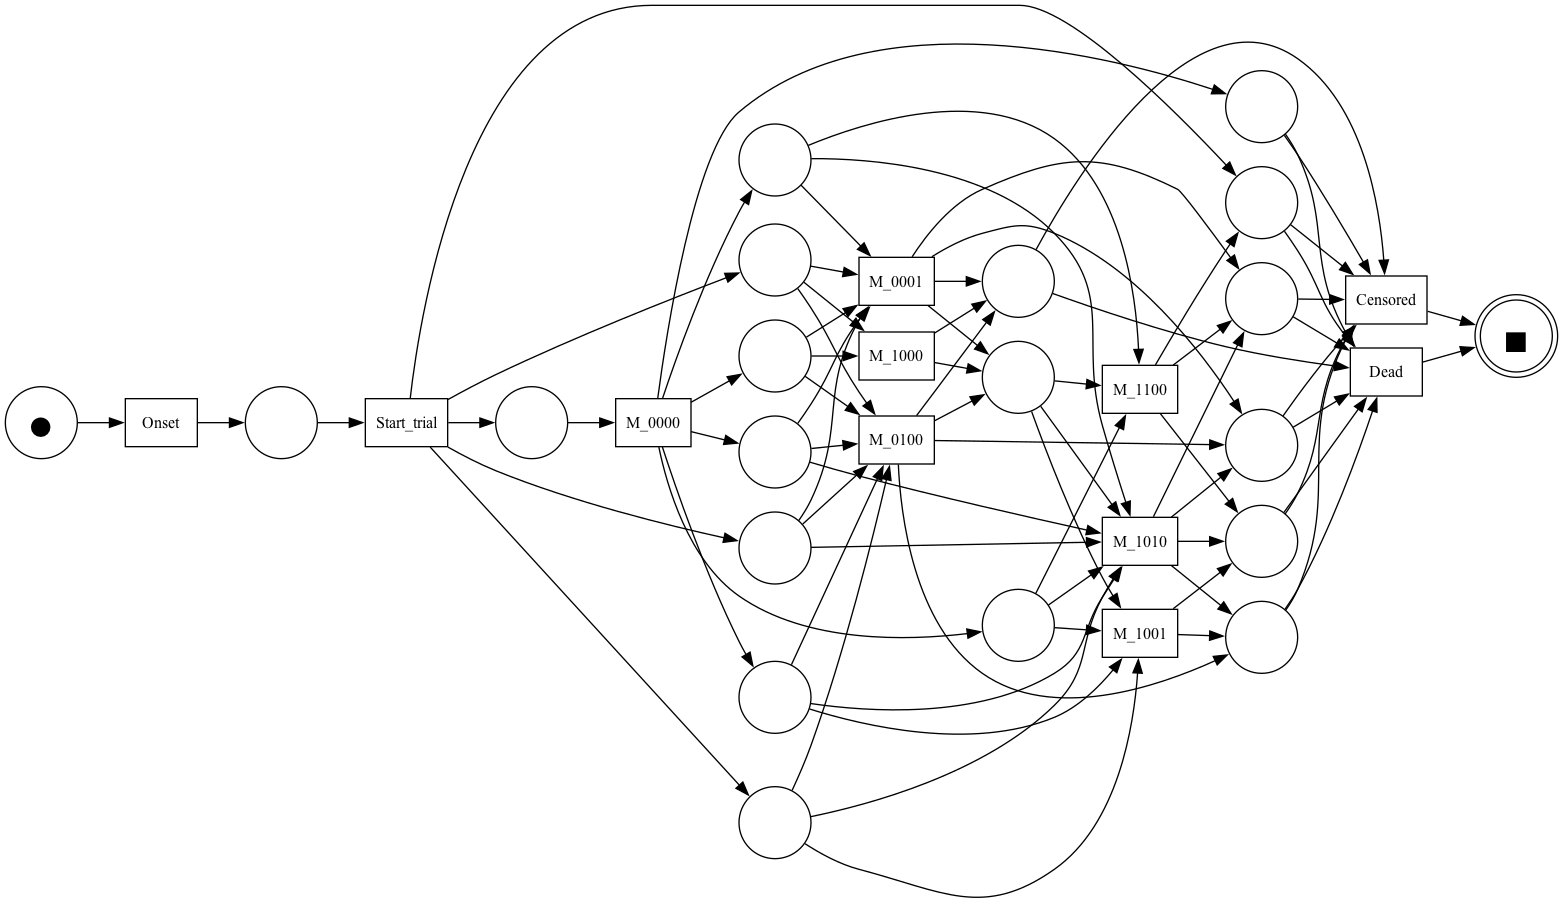

Relations:
 causal
	artificial_start
		{'Onset'}
	Onset
		{'Start_trial'}
	Start_trial
		{'M_0000', 'M_1010', 'M_1001', 'M_0100', 'Dead', 'M_1000', 'M_0001'}
	M_0100
		{'Censored', 'M_1100', 'Dead'}
	Censored
		{'artificial_end'}
	M_0000
		{'M_1010', 'M_1001', 'M_0100', 'Dead', 'M_1000', 'M_0001', 'M_1100', 'Censored'}
	M_1000
		{'M_1001', 'M_1010', 'Dead', 'M_1100', 'Censored'}
	Dead
		{'artificial_end'}
	M_0001
		{'M_1001', 'Censored', 'Dead'}
	M_1001
		{'Censored', 'Dead'}
	M_1010
		{'Censored', 'Dead'}
	M_1100
		{'Dead', 'Censored'}
parallel
follows
	artificial_start
		{'Onset'}
	Onset
		{'Start_trial'}
	Start_trial
		{'M_0000', 'M_1001', 'M_0100', 'M_1010', 'Dead', 'M_1000', 'M_0001'}
	M_0100
		{'Dead', 'M_1100', 'Censored'}
	Censored
		{'artificial_end'}
	M_0000
		{'M_1001', 'M_0100', 'M_1010', 'Dead', 'M_1000', 'M_0001', 'M_1100', 'Censored'}
	M_1000
		{'M_1010', 'M_1001', 'Dead', 'M_1100', 'Censored'}
	Dead
		{'artificial_end'}
	M_0001
		{'Dead', 'Censored', 'M_1001'}
	M_1001
	

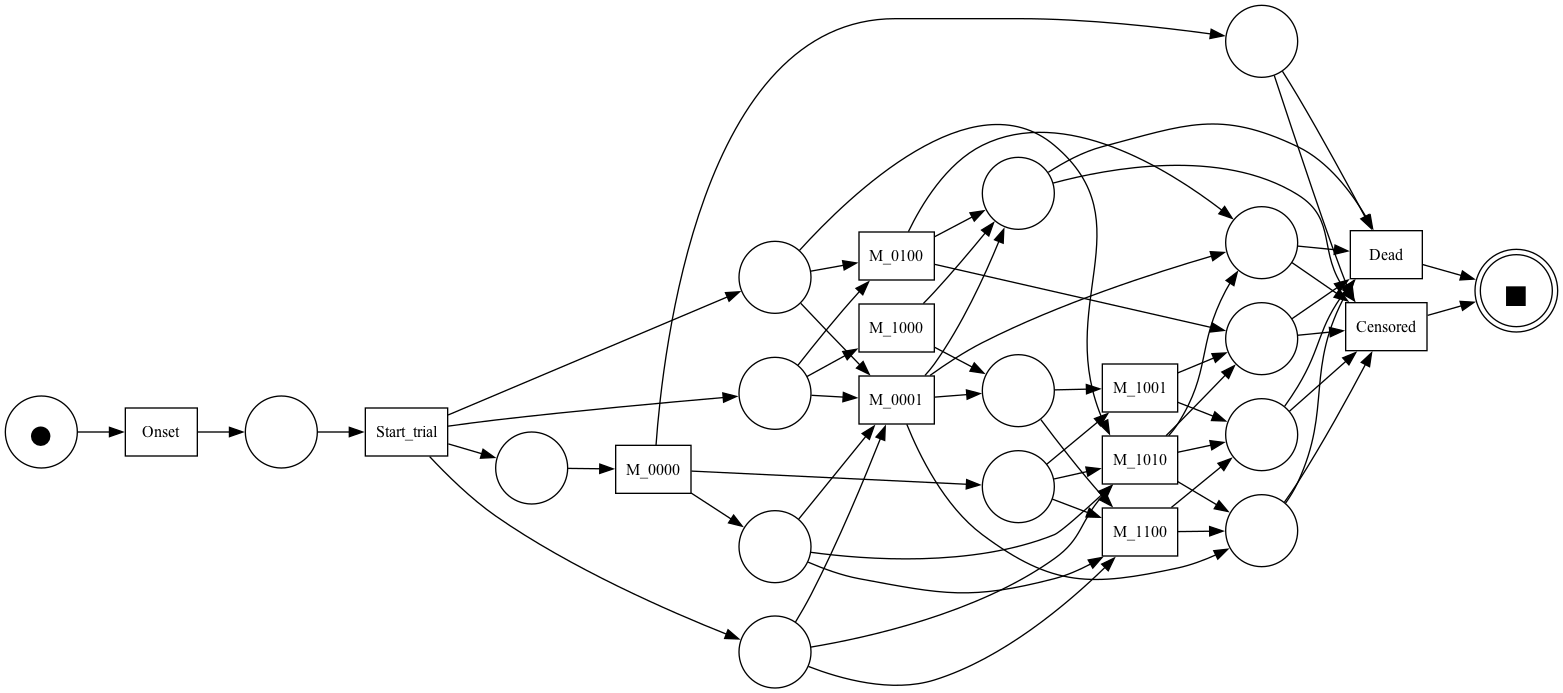

Relations:
 causal
	artificial_start
		{'Onset'}
	Onset
		{'Start_trial'}
	Start_trial
		{'M_0000', 'M_1010', 'M_0100', 'M_1000', 'M_0001', 'M_1100'}
	M_0000
		{'M_1001', 'M_1010', 'Dead', 'M_0001', 'M_1100', 'Censored'}
	M_1000
		{'Dead', 'Censored', 'M_1100', 'M_1001'}
	M_1001
		{'Dead', 'Censored'}
	Dead
		{'artificial_end'}
	M_1100
		{'Censored', 'Dead'}
	Censored
		{'artificial_end'}
	M_0100
		{'Dead', 'Censored'}
	M_1010
		{'Censored', 'Dead'}
	M_0001
		{'Dead', 'Censored', 'M_1001'}
parallel
	M_0000
		{'M_1000', 'M_0100'}
	M_1000
		{'M_0000', 'M_1010'}
	M_1100
		{'M_0100'}
	M_0100
		{'M_0000', 'M_1100'}
	M_1010
		{'M_1000'}
follows
	artificial_start
		{'Onset'}
	Onset
		{'Start_trial'}
	Start_trial
		{'M_0000', 'M_1010', 'M_0100', 'M_1000', 'M_0001', 'M_1100'}
	M_0000
		{'M_1010', 'M_0100', 'M_1001', 'Dead', 'M_1000', 'M_0001', 'M_1100', 'Censored'}
	M_1000
		{'M_0000', 'M_1010', 'M_1001', 'Dead', 'M_1100', 'Censored'}
	M_1001
		{'Censored', 'Dead'}
	Dead
		{'artificial_end'}
	M

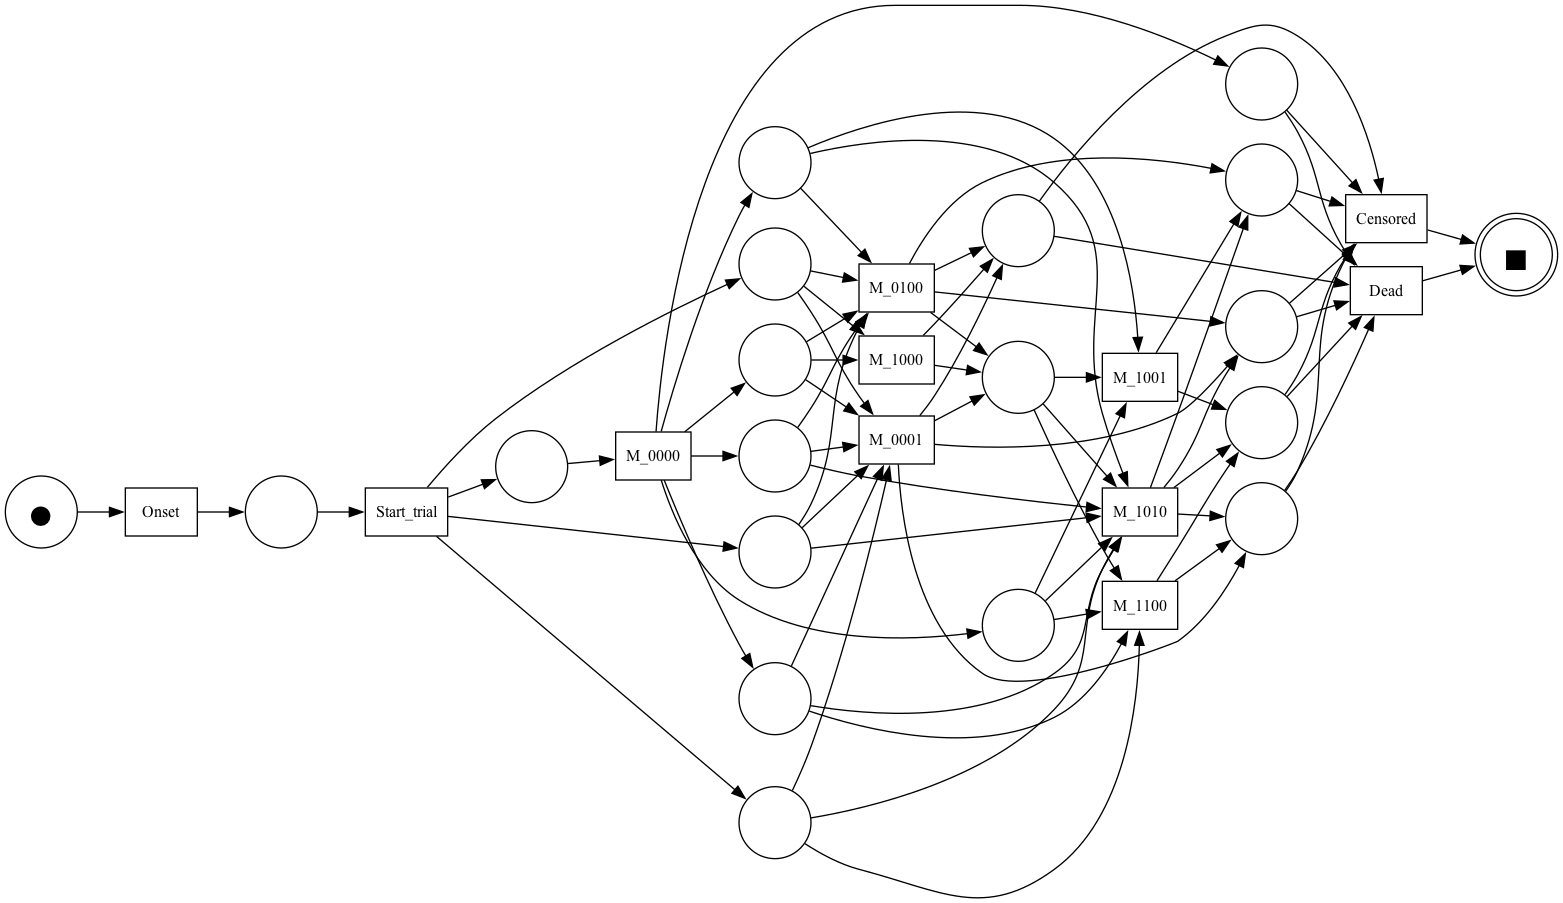

Relations:
 causal
	artificial_start
		{'Onset'}
	Onset
		{'Start_trial'}
	Start_trial
		{'M_0000', 'M_1010', 'M_0100', 'M_1000', 'M_0001', 'M_1100'}
	M_0000
		{'M_1010', 'M_1001', 'M_0100', 'Dead', 'M_1000', 'M_0001', 'M_1100', 'Censored'}
	M_1000
		{'M_1010', 'M_1001', 'Dead', 'M_1100', 'Censored'}
	Censored
		{'artificial_end'}
	M_1001
		{'Censored', 'Dead'}
	M_1010
		{'Censored', 'Dead'}
	M_0100
		{'Censored', 'M_1100', 'Dead'}
	M_1100
		{'Dead', 'Censored'}
	Dead
		{'artificial_end'}
	M_0001
		{'Dead', 'Censored', 'M_1001'}
parallel
follows
	artificial_start
		{'Onset'}
	Onset
		{'Start_trial'}
	Start_trial
		{'M_0000', 'M_1010', 'M_0100', 'M_1000', 'M_0001', 'M_1100'}
	M_0000
		{'M_1001', 'M_0100', 'M_1010', 'Dead', 'M_1000', 'M_0001', 'M_1100', 'Censored'}
	M_1000
		{'M_1001', 'M_1010', 'Dead', 'M_1100', 'Censored'}
	Censored
		{'artificial_end'}
	M_1001
		{'Dead', 'Censored'}
	M_1010
		{'Dead', 'Censored'}
	M_0100
		{'Dead', 'M_1100', 'Censored'}
	M_1100
		{'Censored', 'Dead'}


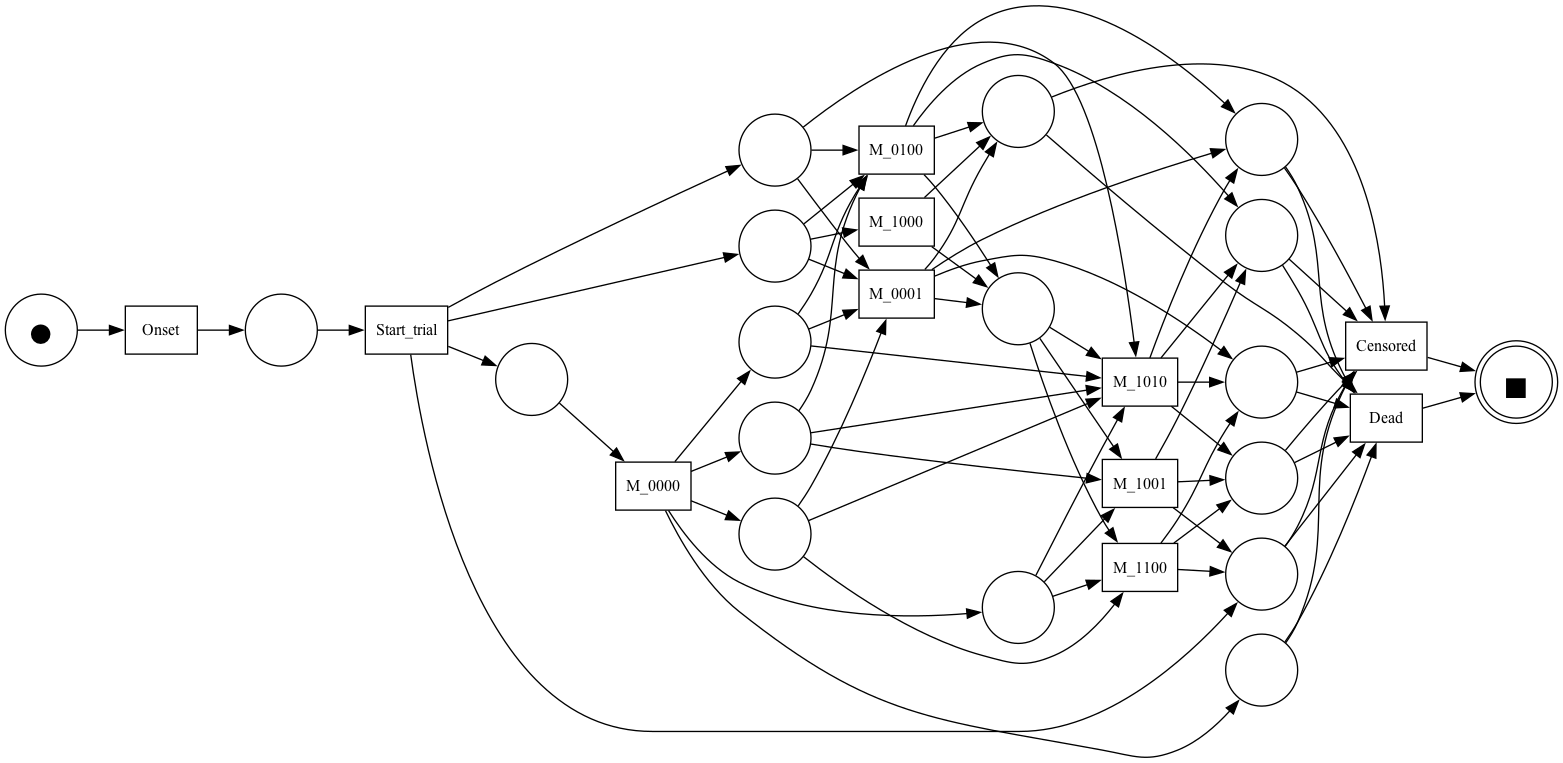

Relations:
 causal
	artificial_start
		{'Onset'}
	Onset
		{'Start_trial'}
	Start_trial
		{'M_0000', 'M_1010', 'M_0100', 'Dead', 'M_1000', 'M_0001', 'Censored'}
	M_0000
		{'M_1001', 'M_1010', 'M_0100', 'Dead', 'M_0001', 'M_1100', 'Censored'}
	Censored
		{'artificial_end'}
	M_1000
		{'M_1010', 'M_1001', 'Dead', 'M_1100', 'Censored'}
	M_1010
		{'Dead', 'Censored'}
	Dead
		{'artificial_end'}
	M_1001
		{'Dead', 'Censored'}
	M_1100
		{'Censored', 'Dead'}
	M_0100
		{'Dead', 'M_1100', 'Censored'}
	M_0001
		{'Dead', 'Censored', 'M_1001'}
parallel
	M_0000
		{'M_1000'}
	M_1000
		{'M_0000'}
follows
	artificial_start
		{'Onset'}
	Onset
		{'Start_trial'}
	Start_trial
		{'M_0000', 'M_1010', 'M_0100', 'Dead', 'M_1000', 'M_0001', 'Censored'}
	M_0000
		{'M_1010', 'M_0100', 'M_1001', 'Dead', 'M_1000', 'M_0001', 'M_1100', 'Censored'}
	Censored
		{'artificial_end'}
	M_1000
		{'M_0000', 'M_1001', 'M_1010', 'Dead', 'M_1100', 'Censored'}
	M_1010
		{'Censored', 'Dead'}
	Dead
		{'artificial_end'}
	M_1001
		{'Ce

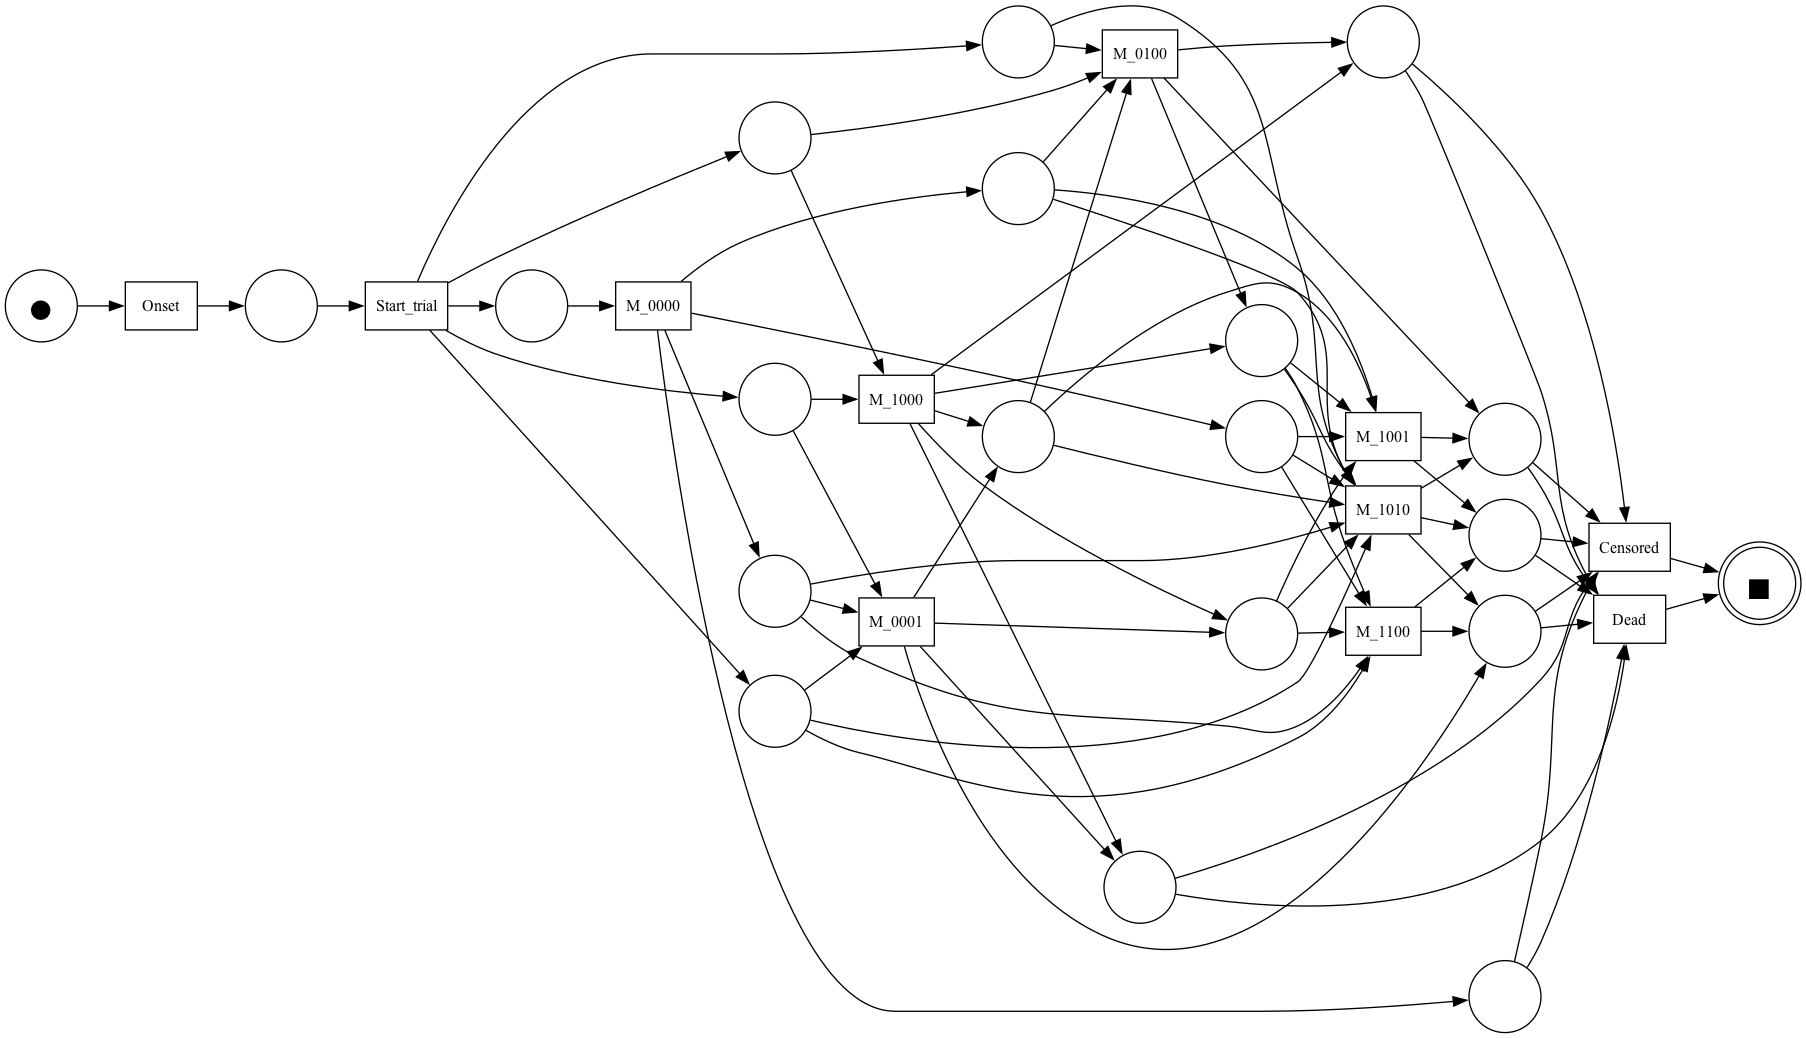

Relations:
 causal
	artificial_start
		{'Onset'}
	Onset
		{'Start_trial'}
	Start_trial
		{'M_0000', 'M_1010', 'M_0100', 'M_1000', 'M_0001', 'M_1100'}
	M_1000
		{'M_1010', 'M_1001', 'Dead', 'M_1100', 'Censored'}
	M_1100
		{'Censored', 'Dead'}
	Censored
		{'artificial_end'}
	M_0000
		{'M_1010', 'M_1001', 'M_0100', 'Dead', 'M_0001', 'M_1100', 'Censored'}
	M_1001
		{'Censored', 'Dead'}
	Dead
		{'artificial_end'}
	M_0100
		{'Censored', 'M_1100', 'Dead'}
	M_1010
		{'Censored', 'Dead'}
	M_0001
		{'M_1001', 'Censored', 'Dead', 'M_0100'}
parallel
	M_1000
		{'M_0000'}
	M_0000
		{'M_1000'}
follows
	artificial_start
		{'Onset'}
	Onset
		{'Start_trial'}
	Start_trial
		{'M_0000', 'M_1010', 'M_0100', 'M_1000', 'M_0001', 'M_1100'}
	M_1000
		{'M_0000', 'M_1001', 'M_1010', 'Dead', 'M_1100', 'Censored'}
	M_1100
		{'Dead', 'Censored'}
	Censored
		{'artificial_end'}
	M_0000
		{'M_1001', 'M_0100', 'M_1010', 'Dead', 'M_1000', 'M_0001', 'M_1100', 'Censored'}
	M_1001
		{'Dead', 'Censored'}
	Dead
		{'artificial

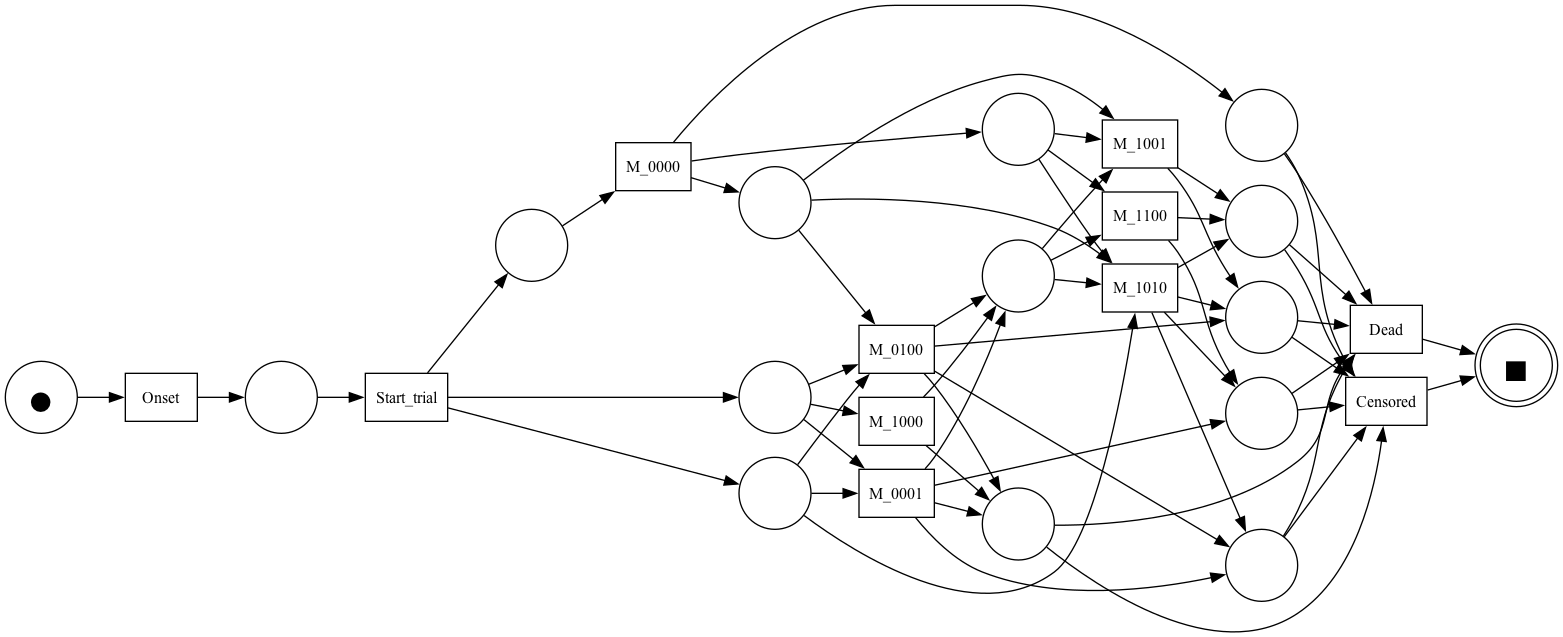

Relations:
 causal
	artificial_start
		{'Onset'}
	Onset
		{'Start_trial'}
	Start_trial
		{'M_0000', 'M_1010', 'M_0100', 'M_1000', 'M_0001'}
	M_1000
		{'M_1001', 'M_1010', 'Dead', 'M_1100', 'Censored'}
	Censored
		{'artificial_end'}
	M_0000
		{'M_1001', 'M_1010', 'M_0100', 'Dead', 'M_1100', 'Censored'}
	Dead
		{'artificial_end'}
	M_0100
		{'Dead', 'M_1100', 'Censored'}
	M_1100
		{'Dead', 'Censored'}
	M_1010
		{'Censored', 'Dead'}
	M_1001
		{'Censored', 'Dead'}
	M_0001
		{'Dead', 'Censored', 'M_1001'}
parallel
	M_1000
		{'M_0000'}
	M_0000
		{'M_0001', 'M_1000'}
	M_0001
		{'M_0000'}
follows
	artificial_start
		{'Onset'}
	Onset
		{'Start_trial'}
	Start_trial
		{'M_0000', 'M_1010', 'M_0100', 'M_1000', 'M_0001'}
	M_1000
		{'M_0000', 'M_1010', 'M_1001', 'Dead', 'M_1100', 'Censored'}
	Censored
		{'artificial_end'}
	M_0000
		{'M_1010', 'M_0100', 'M_1001', 'Dead', 'M_1000', 'M_0001', 'M_1100', 'Censored'}
	Dead
		{'artificial_end'}
	M_0100
		{'Censored', 'M_1100', 'Dead'}
	M_1100
		{'Censored', 

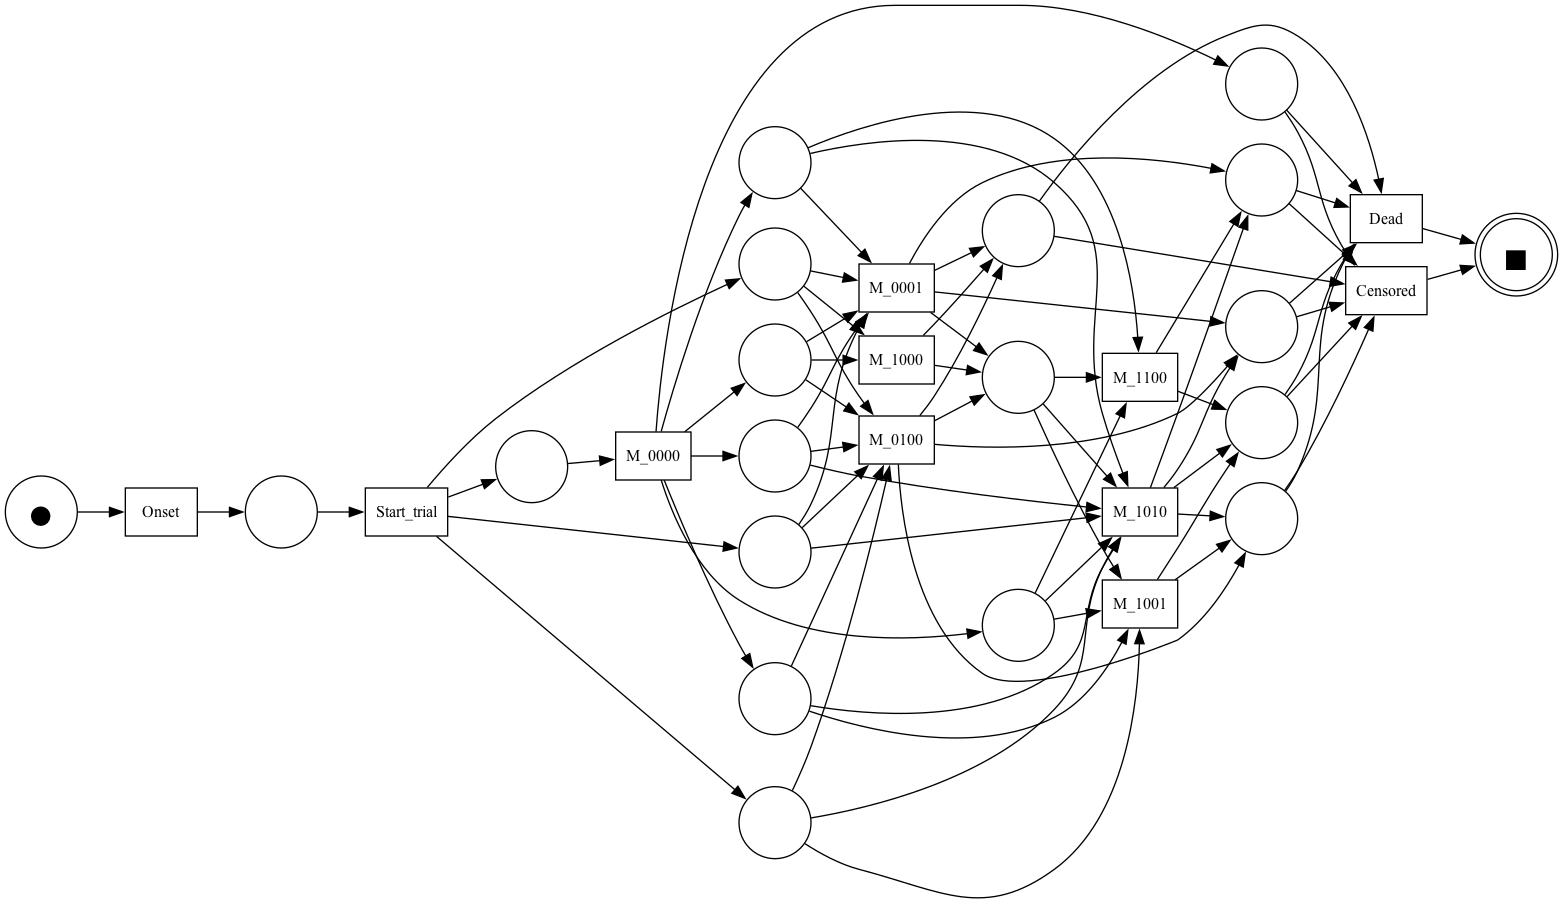

Relations:
 causal
	artificial_start
		{'Onset'}
	Onset
		{'Start_trial'}
	Start_trial
		{'M_0000', 'M_1001', 'M_1010', 'M_0100', 'M_1000', 'M_0001'}
	M_0000
		{'M_1010', 'M_1001', 'M_0100', 'Dead', 'M_1000', 'M_0001', 'M_1100', 'Censored'}
	M_1000
		{'M_1010', 'M_1001', 'Dead', 'M_1100', 'Censored'}
	Censored
		{'artificial_end'}
	M_1100
		{'Censored', 'Dead'}
	M_1001
		{'Dead', 'Censored'}
	Dead
		{'artificial_end'}
	M_0001
		{'Dead', 'Censored', 'M_1001'}
	M_1010
		{'Dead', 'Censored'}
	M_0100
		{'Dead', 'M_1100', 'Censored'}
parallel
follows
	artificial_start
		{'Onset'}
	Onset
		{'Start_trial'}
	Start_trial
		{'M_0000', 'M_1010', 'M_0100', 'M_1001', 'M_1000', 'M_0001'}
	M_0000
		{'M_1001', 'M_0100', 'M_1010', 'Dead', 'M_1000', 'M_0001', 'M_1100', 'Censored'}
	M_1000
		{'M_1001', 'M_1010', 'Dead', 'M_1100', 'Censored'}
	Censored
		{'artificial_end'}
	M_1100
		{'Dead', 'Censored'}
	M_1001
		{'Censored', 'Dead'}
	Dead
		{'artificial_end'}
	M_0001
		{'M_1001', 'Dead', 'Censored'}
	M_1

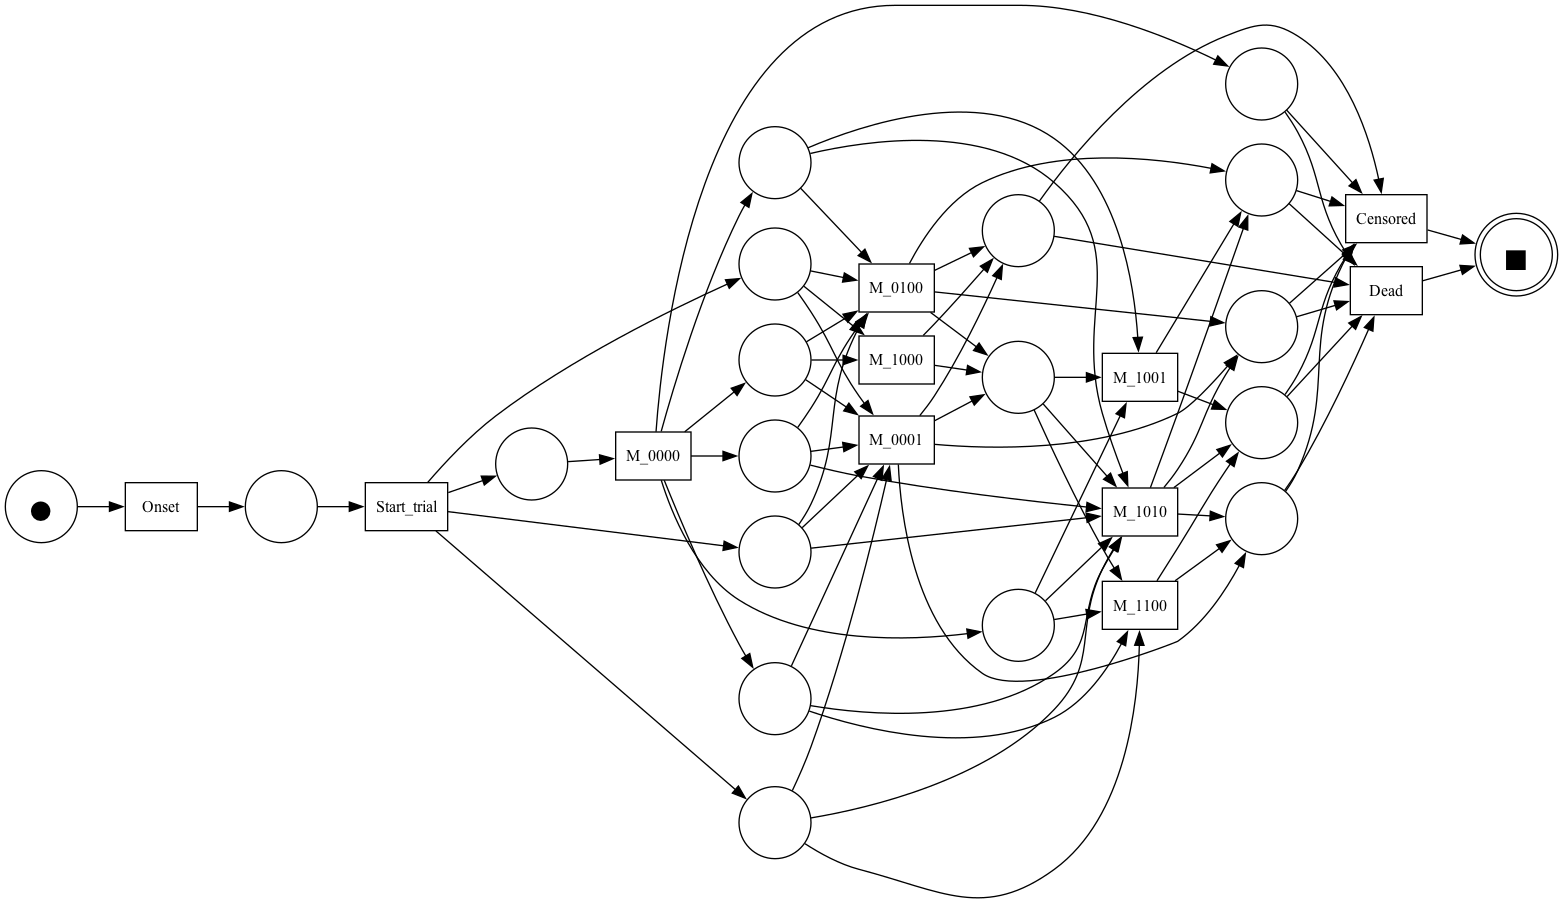

Relations:
 causal
	artificial_start
		{'Onset'}
	Onset
		{'Start_trial'}
	Start_trial
		{'M_0000', 'M_1010', 'M_0100', 'M_1000', 'M_0001', 'M_1100'}
	M_0000
		{'M_1010', 'M_1001', 'M_0100', 'Dead', 'M_1000', 'M_0001', 'M_1100', 'Censored'}
	Censored
		{'artificial_end'}
	M_1000
		{'M_1010', 'M_1001', 'Dead', 'M_1100', 'Censored'}
	M_1010
		{'Dead', 'Censored'}
	Dead
		{'artificial_end'}
	M_0001
		{'Dead', 'Censored', 'M_1001'}
	M_1001
		{'Censored', 'Dead'}
	M_0100
		{'Censored', 'M_1100', 'Dead'}
	M_1100
		{'Censored', 'Dead'}
parallel
follows
	artificial_start
		{'Onset'}
	Onset
		{'Start_trial'}
	Start_trial
		{'M_0000', 'M_1010', 'M_0100', 'M_1000', 'M_0001', 'M_1100'}
	M_0000
		{'M_1001', 'M_0100', 'M_1010', 'Dead', 'M_1000', 'M_0001', 'M_1100', 'Censored'}
	Censored
		{'artificial_end'}
	M_1000
		{'M_1001', 'M_1010', 'Dead', 'M_1100', 'Censored'}
	M_1010
		{'Censored', 'Dead'}
	Dead
		{'artificial_end'}
	M_0001
		{'M_1001', 'Dead', 'Censored'}
	M_1001
		{'Dead', 'Censored'}
	M_0

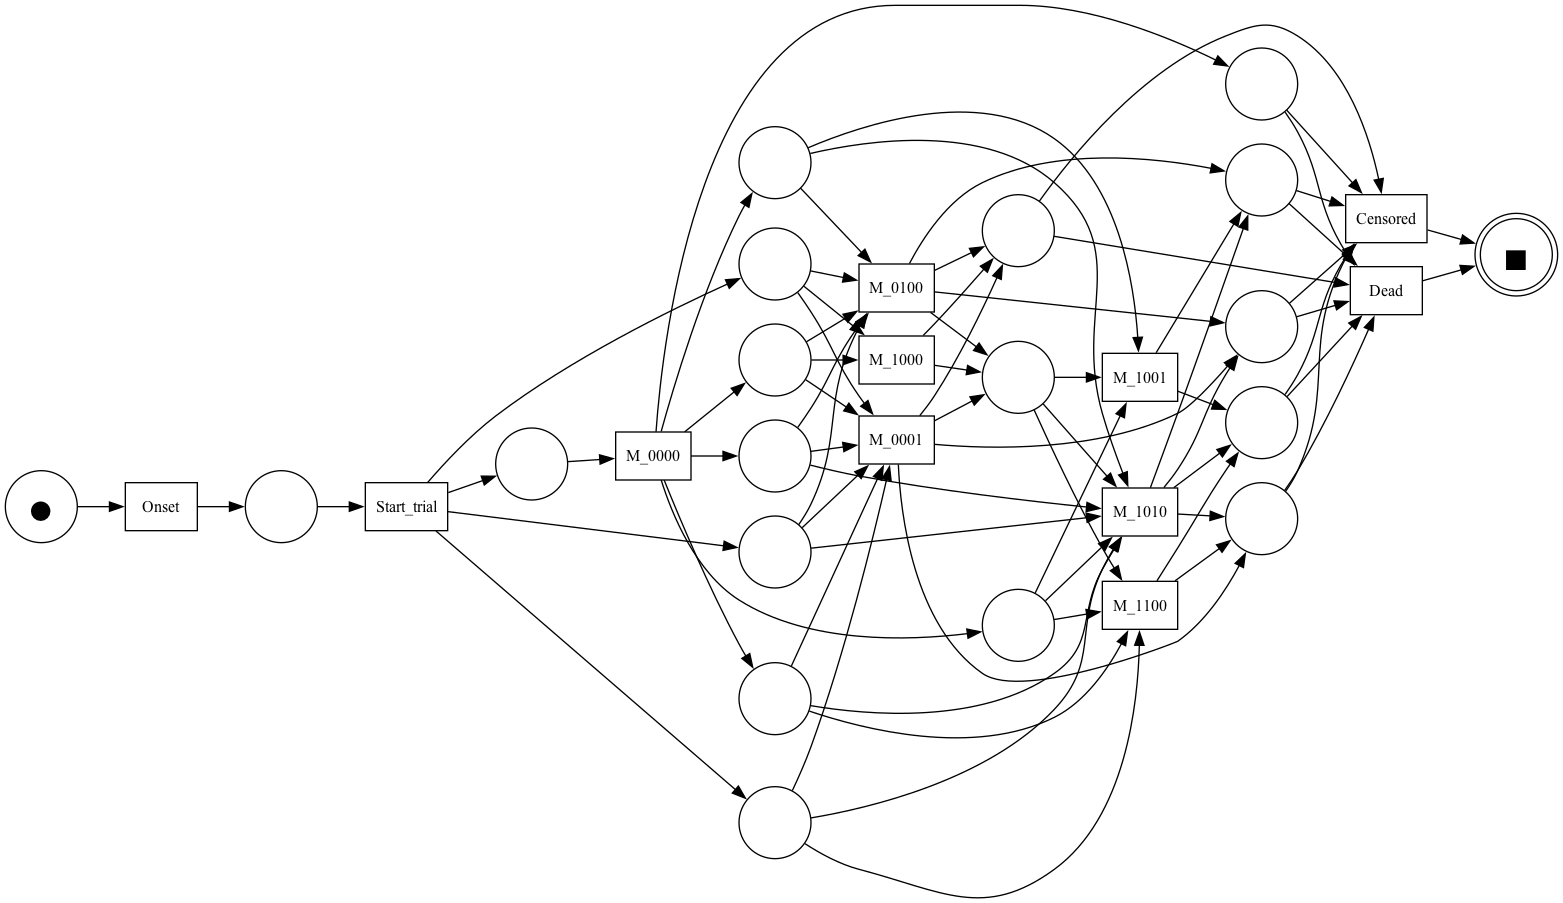

Relations:
 causal
	artificial_start
		{'Onset'}
	Onset
		{'Start_trial'}
	Start_trial
		{'M_0000', 'M_1010', 'M_0100', 'M_1000', 'M_0001', 'M_1100'}
	M_0000
		{'M_1001', 'M_1010', 'M_0100', 'Dead', 'M_1000', 'M_0001', 'M_1100', 'Censored'}
	M_1000
		{'M_1001', 'M_1010', 'Dead', 'M_1100', 'Censored'}
	M_1001
		{'Dead', 'Censored'}
	Dead
		{'artificial_end'}
	M_0100
		{'Censored', 'M_1100', 'Dead'}
	Censored
		{'artificial_end'}
	M_1010
		{'Censored', 'Dead'}
	M_1100
		{'Censored', 'Dead'}
	M_0001
		{'Dead', 'Censored', 'M_1001'}
parallel
follows
	artificial_start
		{'Onset'}
	Onset
		{'Start_trial'}
	Start_trial
		{'M_0000', 'M_1010', 'M_0100', 'M_1000', 'M_0001', 'M_1100'}
	M_0000
		{'M_1010', 'M_0100', 'M_1001', 'Dead', 'M_1000', 'M_0001', 'M_1100', 'Censored'}
	M_1000
		{'M_1010', 'M_1001', 'Dead', 'M_1100', 'Censored'}
	M_1001
		{'Censored', 'Dead'}
	Dead
		{'artificial_end'}
	M_0100
		{'Dead', 'M_1100', 'Censored'}
	Censored
		{'artificial_end'}
	M_1010
		{'Dead', 'Censored'}
	M_1

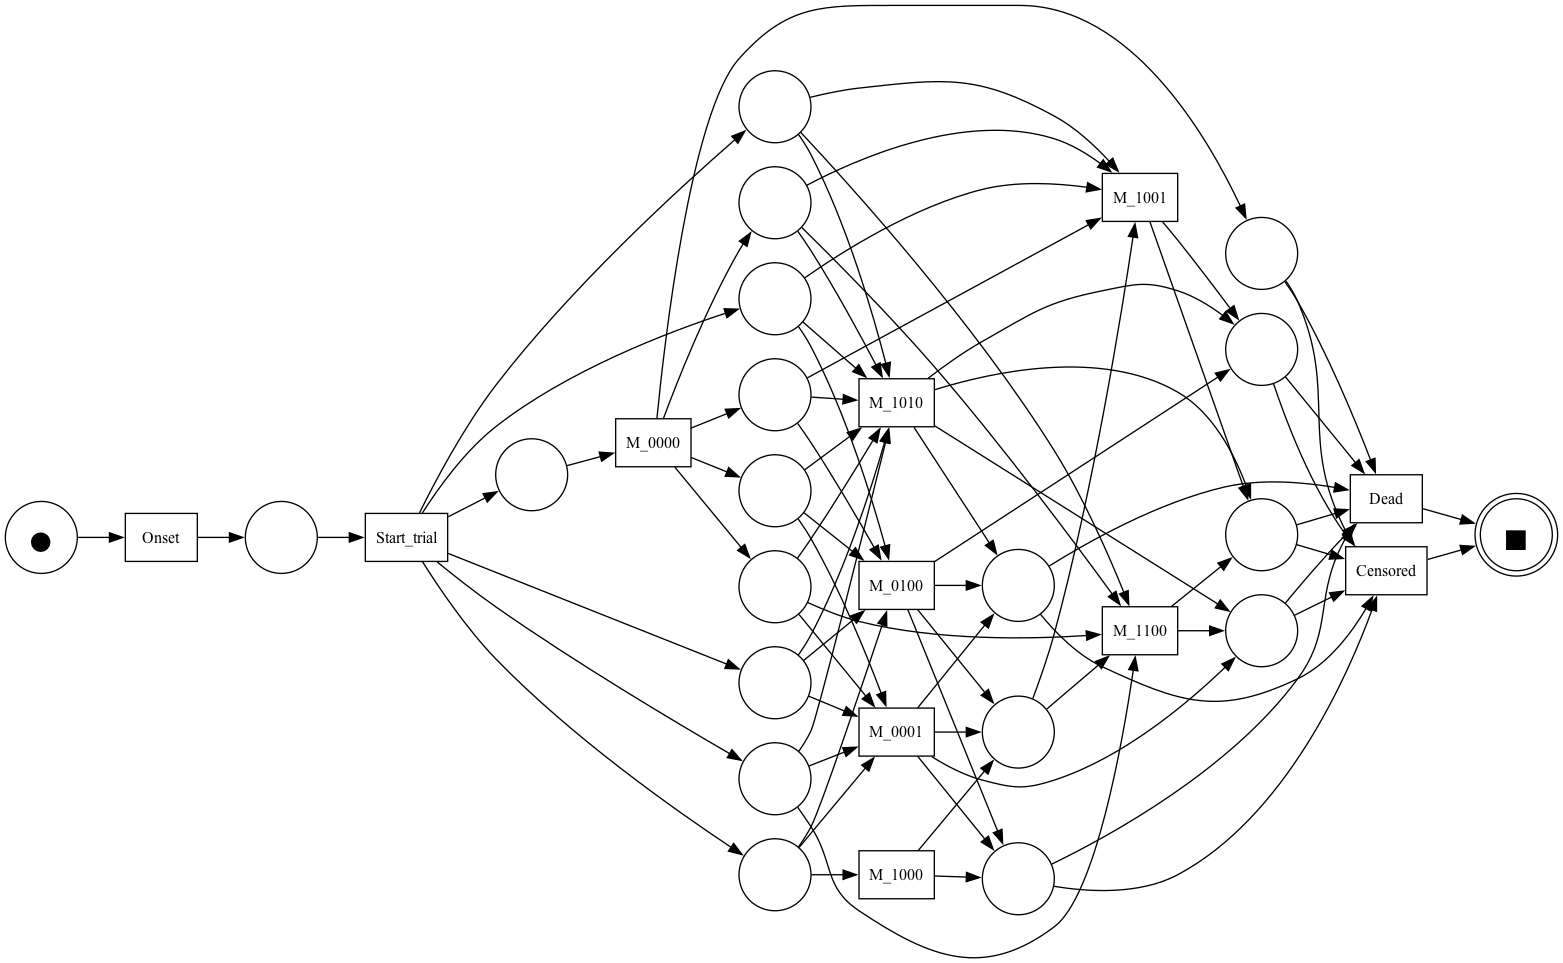

Relations:
 causal
	artificial_start
		{'Onset'}
	Onset
		{'Start_trial'}
	Start_trial
		{'M_0000', 'M_1001', 'M_1010', 'M_0100', 'M_1000', 'M_0001', 'M_1100'}
	M_0001
		{'Dead', 'Censored', 'M_1001'}
	Censored
		{'artificial_end'}
	M_0000
		{'M_1001', 'M_1010', 'M_0100', 'Dead', 'M_0001', 'M_1100', 'Censored'}
	M_1000
		{'Dead', 'Censored', 'M_1100', 'M_1001'}
	M_1001
		{'Censored', 'Dead'}
	Dead
		{'artificial_end'}
	M_0100
		{'Censored', 'M_1100', 'Dead'}
	M_1100
		{'Dead', 'Censored'}
	M_1010
		{'Censored', 'Dead'}
parallel
	M_0000
		{'M_1000'}
	M_1000
		{'M_0000', 'M_1010'}
	M_1010
		{'M_1000'}
follows
	artificial_start
		{'Onset'}
	Onset
		{'Start_trial'}
	Start_trial
		{'M_0000', 'M_1010', 'M_0100', 'M_1001', 'M_1000', 'M_0001', 'M_1100'}
	M_0001
		{'M_1001', 'Dead', 'Censored'}
	Censored
		{'artificial_end'}
	M_0000
		{'M_1010', 'M_0100', 'M_1001', 'Dead', 'M_1000', 'M_0001', 'M_1100', 'Censored'}
	M_1000
		{'M_0000', 'M_1010', 'M_1001', 'Dead', 'M_1100', 'Censored'}
	M_1001
		

In [6]:
FTs, oneL_inputs_dic, oneL_outputs_dic, loop_one_tot_list = simulate_nodes_computation(el_splits=el_splits)

### Master Node

Collected footprint matrices are aggregated and used along with 1-length loop information to run the AA+ algorithm in the master node

In [7]:
sum_FT, events = pm4py.algo.discovery.alpha.variants.plus.aggregate_fms(fts=FTs)

print('Aggregated Footprint Matrix:\n')
display(sum_FT)

print('Total Footprint Matrix:\n')
display(footprint_matrix_tot)

print(f'Equality Check between Total Footprint and Aggregated Footprint Matrix: {footprint_matrix_tot.equals(sum_FT)}\n')

assert footprint_matrix_tot.equals(sum_FT)

Footprint Matrices to aggregate:



,artificial_start,artificial_end,Censored,Dead,M_0000,M_0001,M_0100,M_1000,M_1001,M_1010,M_1100,Onset,Start_trial
artificial_start,#,#,#,#,#,#,#,#,#,#,#,->,#
artificial_end,#,#,<-,<-,#,#,#,#,#,#,#,#,#
Censored,#,->,#,#,<-,<-,<-,<-,<-,<-,<-,#,#
Dead,#,->,#,#,<-,<-,<-,<-,<-,<-,<-,#,<-
M_0000,#,#,->,->,#,->,->,->,->,->,->,#,<-
M_0001,#,#,->,->,<-,#,#,#,->,#,#,#,<-
M_0100,#,#,->,->,<-,#,#,#,#,#,->,#,<-
M_1000,#,#,->,->,<-,#,#,#,->,->,->,#,<-
M_1001,#,#,->,->,<-,<-,#,<-,#,#,#,#,<-
M_1010,#,#,->,->,<-,#,#,<-,#,#,#,#,<-


,artificial_start,artificial_end,Censored,Dead,M_0000,M_0001,M_0100,M_1000,M_1001,M_1010,M_1100,Onset,Start_trial
artificial_start,#,#,#,#,#,#,#,#,#,#,#,->,#
artificial_end,#,#,<-,<-,#,#,#,#,#,#,#,#,#
Censored,#,->,#,#,<-,<-,<-,<-,<-,<-,<-,#,#
Dead,#,->,#,#,<-,<-,<-,<-,<-,<-,<-,#,#
M_0000,#,#,->,->,#,->,||,||,->,->,->,#,<-
M_0001,#,#,->,->,<-,#,#,#,->,#,#,#,<-
M_0100,#,#,->,->,T,#,#,#,#,#,||,#,<-
M_1000,#,#,->,->,T,#,#,#,->,||,->,#,<-
M_1001,#,#,->,->,<-,<-,#,<-,#,#,#,#,#
M_1010,#,#,->,->,<-,#,#,T,#,#,#,#,<-


,artificial_start,artificial_end,Censored,Dead,M_0000,M_0001,M_0100,M_1000,M_1001,M_1010,M_1100,Onset,Start_trial
artificial_start,#,#,#,#,#,#,#,#,#,#,#,->,#
artificial_end,#,#,<-,<-,#,#,#,#,#,#,#,#,#
Censored,#,->,#,#,<-,<-,<-,<-,<-,<-,<-,#,#
Dead,#,->,#,#,<-,<-,<-,<-,<-,<-,<-,#,#
M_0000,#,#,->,->,#,->,->,->,->,->,->,#,<-
M_0001,#,#,->,->,<-,#,#,#,->,#,#,#,<-
M_0100,#,#,->,->,<-,#,#,#,#,#,->,#,<-
M_1000,#,#,->,->,<-,#,#,#,->,->,->,#,<-
M_1001,#,#,->,->,<-,<-,#,<-,#,#,#,#,#
M_1010,#,#,->,->,<-,#,#,<-,#,#,#,#,<-


,artificial_start,artificial_end,Censored,Dead,M_0000,M_0001,M_0100,M_1000,M_1001,M_1010,M_1100,Onset,Start_trial
artificial_start,#,#,#,#,#,#,#,#,#,#,#,->,#
artificial_end,#,#,<-,<-,#,#,#,#,#,#,#,#,#
Censored,#,->,#,#,<-,<-,<-,<-,<-,<-,<-,#,<-
Dead,#,->,#,#,<-,<-,<-,<-,<-,<-,<-,#,<-
M_0000,#,#,->,->,#,->,->,||,->,->,->,#,<-
M_0001,#,#,->,->,<-,#,#,#,->,#,#,#,<-
M_0100,#,#,->,->,<-,#,#,#,#,#,->,#,<-
M_1000,#,#,->,->,T,#,#,#,->,->,->,#,<-
M_1001,#,#,->,->,<-,<-,#,<-,#,#,#,#,#
M_1010,#,#,->,->,<-,#,#,<-,#,#,#,#,<-


...



Aggregated Footprint Matrix:



,artificial_start,artificial_end,Censored,Dead,M_0000,M_0001,M_0100,M_1000,M_1001,M_1010,M_1100,Onset,Start_trial
artificial_start,#,#,#,#,#,#,#,#,#,#,#,->,#
artificial_end,#,#,<-,<-,#,#,#,#,#,#,#,#,#
Censored,#,->,#,#,<-,<-,<-,<-,<-,<-,<-,#,<-
Dead,#,->,#,#,<-,<-,<-,<-,<-,<-,<-,#,<-
M_0000,#,#,->,->,#,||,||,||,->,->,->,#,<-
M_0001,#,#,->,->,||,#,->,#,->,#,#,#,<-
M_0100,#,#,->,->,T,<-,#,#,#,#,||,#,<-
M_1000,#,#,->,->,T,#,#,#,->,||,->,#,<-
M_1001,#,#,->,->,<-,<-,#,<-,#,#,#,#,<-
M_1010,#,#,->,->,<-,#,#,T,#,#,#,#,<-


Total Footprint Matrix:



,artificial_start,artificial_end,Censored,Dead,M_0000,M_0001,M_0100,M_1000,M_1001,M_1010,M_1100,Onset,Start_trial
artificial_start,#,#,#,#,#,#,#,#,#,#,#,->,#
artificial_end,#,#,<-,<-,#,#,#,#,#,#,#,#,#
Censored,#,->,#,#,<-,<-,<-,<-,<-,<-,<-,#,<-
Dead,#,->,#,#,<-,<-,<-,<-,<-,<-,<-,#,<-
M_0000,#,#,->,->,#,||,||,||,->,->,->,#,<-
M_0001,#,#,->,->,||,#,->,#,->,#,#,#,<-
M_0100,#,#,->,->,T,<-,#,#,#,#,||,#,<-
M_1000,#,#,->,->,T,#,#,#,->,||,->,#,<-
M_1001,#,#,->,->,<-,<-,#,<-,#,#,#,#,<-
M_1010,#,#,->,->,<-,#,#,T,#,#,#,#,<-


Equality Check between Total Footprint and Aggregated Footprint Matrix: True



#### AA+

1-length-loop free net soundness: False


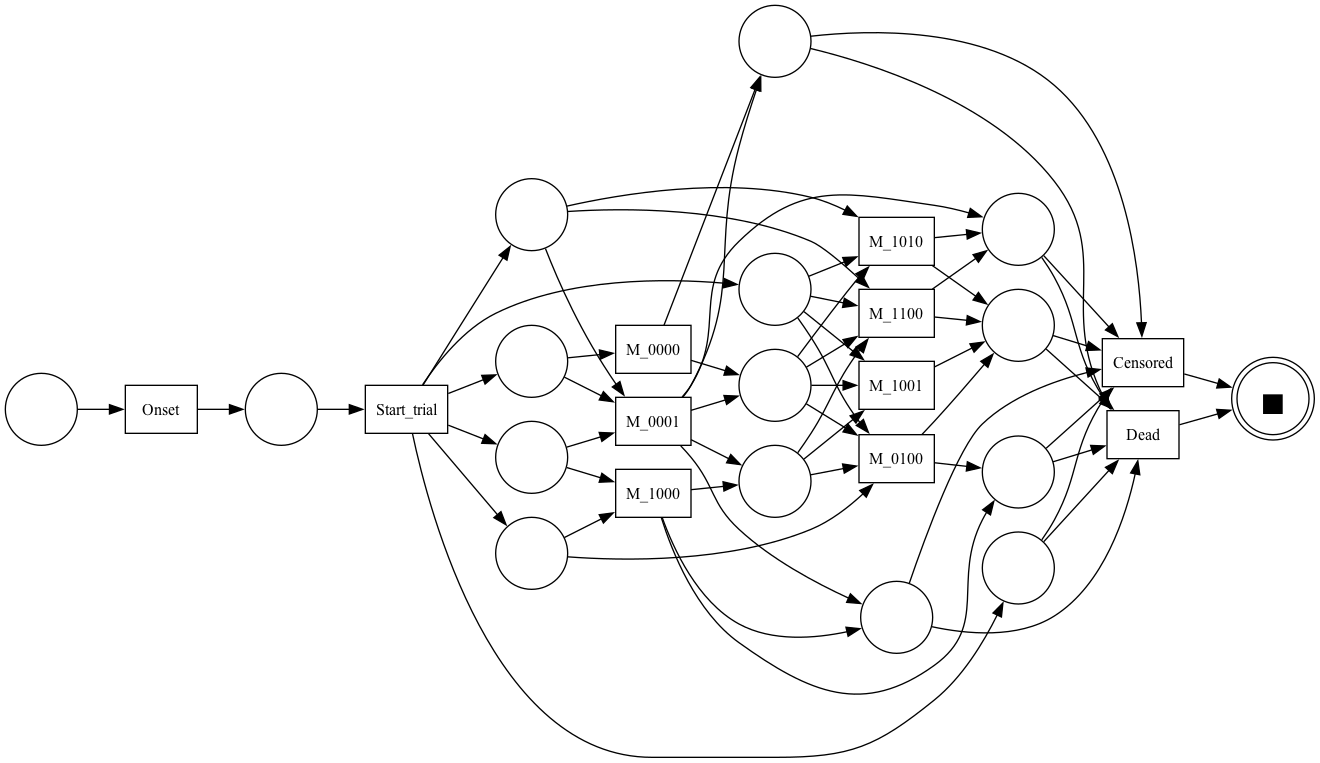

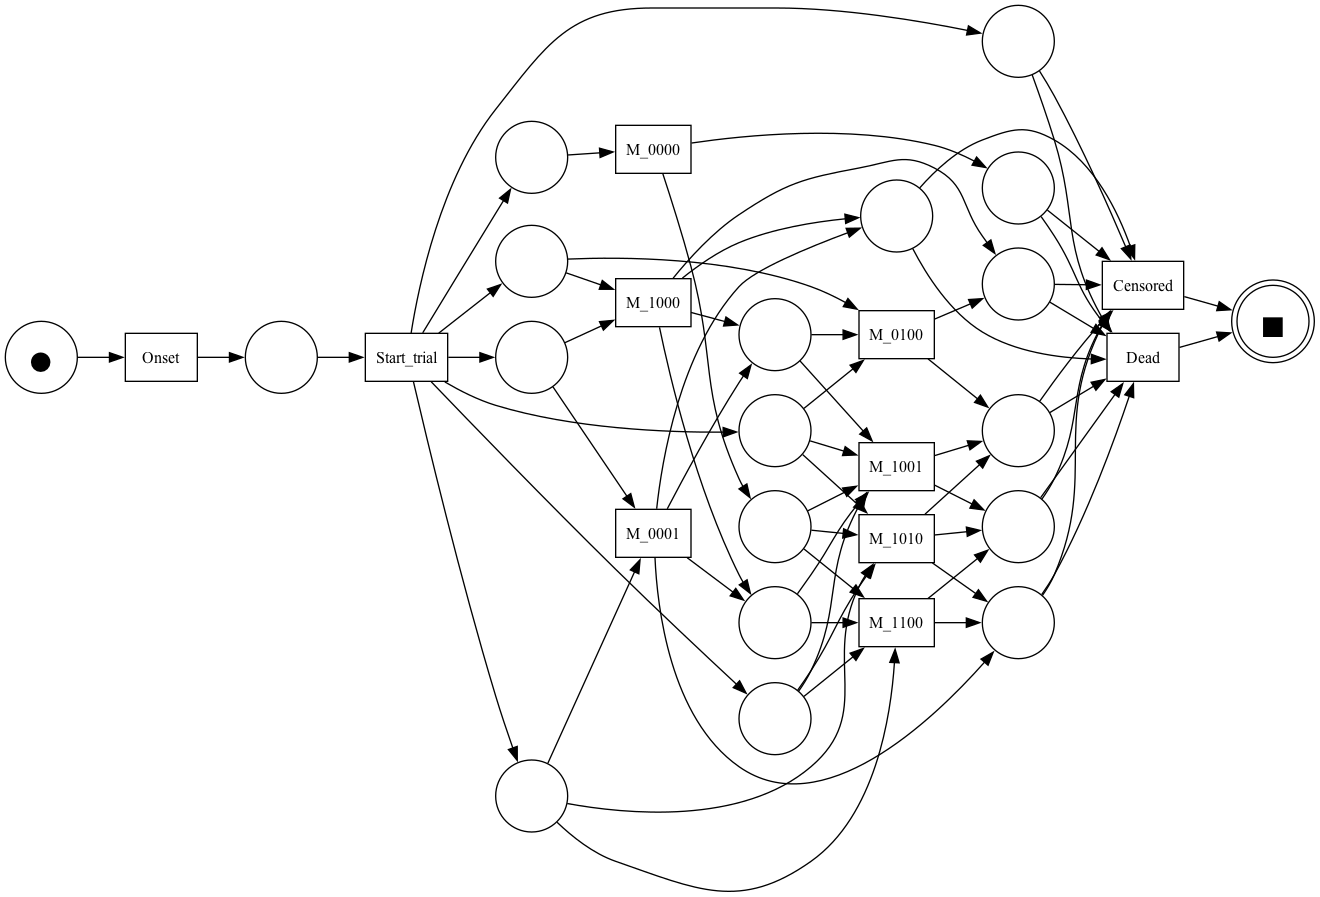

In [8]:
net_final, initial_marking_final, final_marking_final = apply_aggr(fm=sum_FT,
                                                                   events=events,
                                                                   oneL_inputs=oneL_inputs_dic,
                                                                   oneL_outputs=oneL_outputs_dic,
                                                                   loop_one_list=loop_one_list_tot
                                                                   )

pm4py.view_petri_net(net_final, initial_marking_final, final_marking_final)
pm4py.view_petri_net(net_tot, initial_marking_tot, final_marking_tot)

# In Vitro Testing
Same procedure is repeated using in vitro EL. EL.csv is splitted in A,B and C subsplits each containing a subset of loops.

In [9]:
event_log_tot_vitro, _ = load_convert_el(el_path=r"./data/EL.csv", case_id='Case_ID', activity_key='Activity', timestamp_key='Timestamp')

el_splits_vitro = []
event_log_A, _ = load_convert_el(el_path=r"./data/EL_A.csv", case_id='Case_ID', activity_key='Activity', timestamp_key='Timestamp')
event_log_B, _ = load_convert_el(el_path=r"./data/EL_B.csv", case_id='Case_ID', activity_key='Activity', timestamp_key='Timestamp')
event_log_C, _ = load_convert_el(el_path=r"./data/EL_C.csv", case_id='Case_ID', activity_key='Activity', timestamp_key='Timestamp')
el_splits_vitro.append(event_log_A)
el_splits_vitro.append(event_log_B)
el_splits_vitro.append(event_log_C)


Entire Event Log (Alpha+):
1-length-loop free net soundness: True


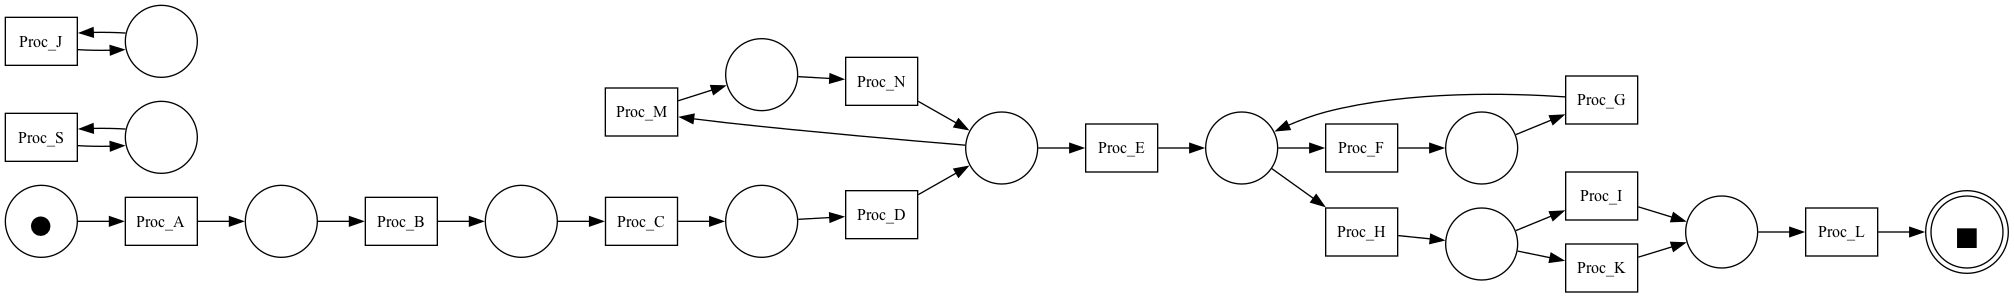

Relations:
 causal
	artificial_start
		{'Proc_A'}
	Proc_A
		{'Proc_B'}
	Proc_B
		{'Proc_C'}
	Proc_C
		{'Proc_D'}
	Proc_D
		{'Proc_M', 'Proc_E'}
	Proc_E
		{'Proc_F'}
	Proc_F
		{'Proc_G'}
	Proc_G
		{'Proc_F', 'Proc_H'}
	Proc_H
		{'Proc_I', 'Proc_K'}
	Proc_I
		{'Proc_L'}
	Proc_L
		{'artificial_end'}
	Proc_M
		{'Proc_N'}
	Proc_N
		{'Proc_M', 'Proc_E'}
	Proc_K
		{'Proc_L'}
parallel
follows
	artificial_start
		{'Proc_A'}
	Proc_A
		{'Proc_B'}
	Proc_B
		{'Proc_C'}
	Proc_C
		{'Proc_D'}
	Proc_D
		{'Proc_M', 'Proc_E'}
	Proc_E
		{'Proc_F'}
	Proc_F
		{'Proc_G'}
	Proc_G
		{'Proc_F', 'Proc_H'}
	Proc_H
		{'Proc_I', 'Proc_K'}
	Proc_I
		{'Proc_L'}
	Proc_L
		{'artificial_end'}
	Proc_M
		{'Proc_N'}
	Proc_N
		{'Proc_M', 'Proc_E'}
	Proc_K
		{'Proc_L'}
square
	Proc_F
		{'Proc_G'}
	Proc_G
		{'Proc_F'}
	Proc_M
		{'Proc_N'}
	Proc_N
		{'Proc_M'}
triangle
	Proc_F
		{'Proc_G'}
	Proc_G
		{'Proc_F'}
	Proc_M
		{'Proc_N'}
	Proc_N
		{'Proc_M'}

Length One Loop Inputs:
 Proc_S
	{'Proc_C'}
Proc_J
	{'Proc_B'}

Length One 

In [10]:
print('\nEntire Event Log (Alpha+):')
net_tot_vitro, initial_marking_tot_vitro, final_marking_tot_vitro, footprint_matrix_tot_vitro, loop_one_list_tot_vitro, oneL_inputs_tot_vitro, oneL_outputs_tot_vitro= apply_monocentric(event_log_tot_vitro)

1-length-loop free net soundness: True


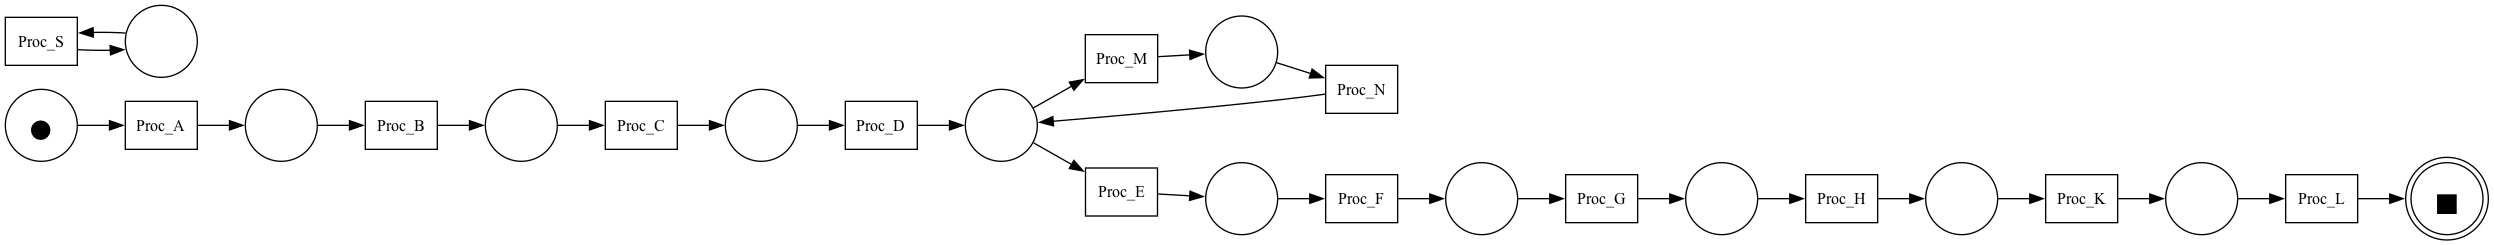

Relations:
 causal
	artificial_start
		{'Proc_A'}
	Proc_A
		{'Proc_B'}
	Proc_B
		{'Proc_C'}
	Proc_C
		{'Proc_D'}
	Proc_D
		{'Proc_M'}
	Proc_M
		{'Proc_N'}
	Proc_N
		{'Proc_M', 'Proc_E'}
	Proc_E
		{'Proc_F'}
	Proc_F
		{'Proc_G'}
	Proc_G
		{'Proc_H'}
	Proc_H
		{'Proc_K'}
	Proc_K
		{'Proc_L'}
	Proc_L
		{'artificial_end'}
parallel
follows
	artificial_start
		{'Proc_A'}
	Proc_A
		{'Proc_B'}
	Proc_B
		{'Proc_C'}
	Proc_C
		{'Proc_D'}
	Proc_D
		{'Proc_M'}
	Proc_M
		{'Proc_N'}
	Proc_N
		{'Proc_M', 'Proc_E'}
	Proc_E
		{'Proc_F'}
	Proc_F
		{'Proc_G'}
	Proc_G
		{'Proc_H'}
	Proc_H
		{'Proc_K'}
	Proc_K
		{'Proc_L'}
	Proc_L
		{'artificial_end'}
square
	Proc_M
		{'Proc_N'}
	Proc_N
		{'Proc_M'}
triangle
	Proc_M
		{'Proc_N'}
	Proc_N
		{'Proc_M'}

Length One Loop Inputs:
 Proc_S
	{'Proc_C'}

Length One Loop Outputs:
 Proc_S
	{'Proc_D'}

1-length-loop free net soundness: True


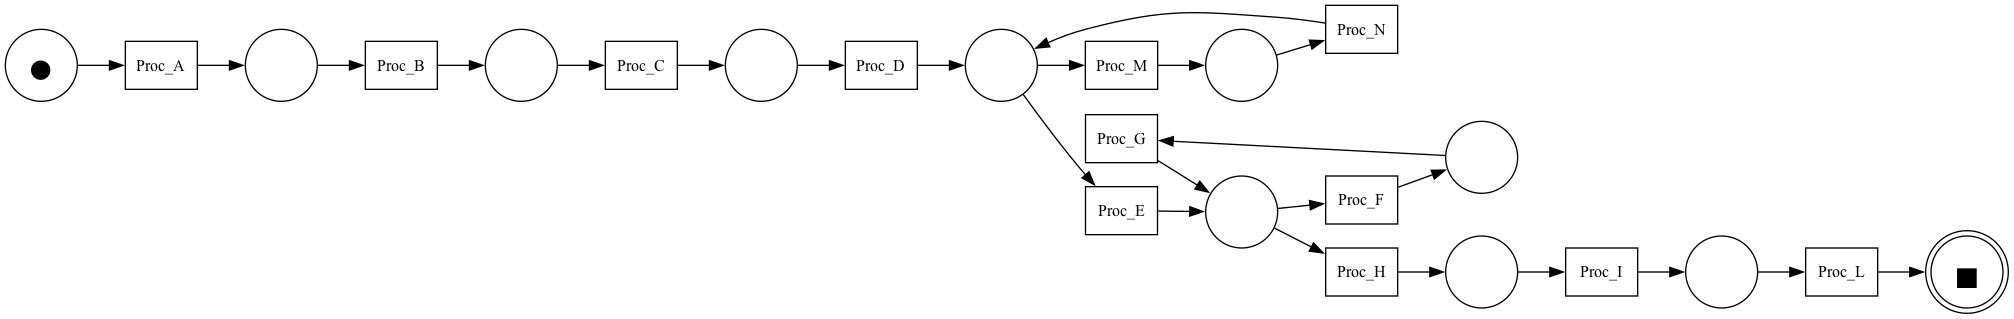

Relations:
 causal
	artificial_start
		{'Proc_A'}
	Proc_A
		{'Proc_B'}
	Proc_B
		{'Proc_C'}
	Proc_C
		{'Proc_D'}
	Proc_D
		{'Proc_M', 'Proc_E'}
	Proc_E
		{'Proc_F'}
	Proc_F
		{'Proc_G'}
	Proc_G
		{'Proc_F', 'Proc_H'}
	Proc_H
		{'Proc_I'}
	Proc_I
		{'Proc_L'}
	Proc_L
		{'artificial_end'}
	Proc_M
		{'Proc_N'}
	Proc_N
		{'Proc_M', 'Proc_E'}
parallel
follows
	artificial_start
		{'Proc_A'}
	Proc_A
		{'Proc_B'}
	Proc_B
		{'Proc_C'}
	Proc_C
		{'Proc_D'}
	Proc_D
		{'Proc_M', 'Proc_E'}
	Proc_E
		{'Proc_F'}
	Proc_F
		{'Proc_G'}
	Proc_G
		{'Proc_F', 'Proc_H'}
	Proc_H
		{'Proc_I'}
	Proc_I
		{'Proc_L'}
	Proc_L
		{'artificial_end'}
	Proc_M
		{'Proc_N'}
	Proc_N
		{'Proc_M', 'Proc_E'}
square
	Proc_F
		{'Proc_G'}
	Proc_G
		{'Proc_F'}
	Proc_M
		{'Proc_N'}
	Proc_N
		{'Proc_M'}
triangle
	Proc_F
		{'Proc_G'}
	Proc_G
		{'Proc_F'}
	Proc_M
		{'Proc_N'}
	Proc_N
		{'Proc_M'}

Length One Loop Inputs:
 
Length One Loop Outputs:
 
1-length-loop free net soundness: True


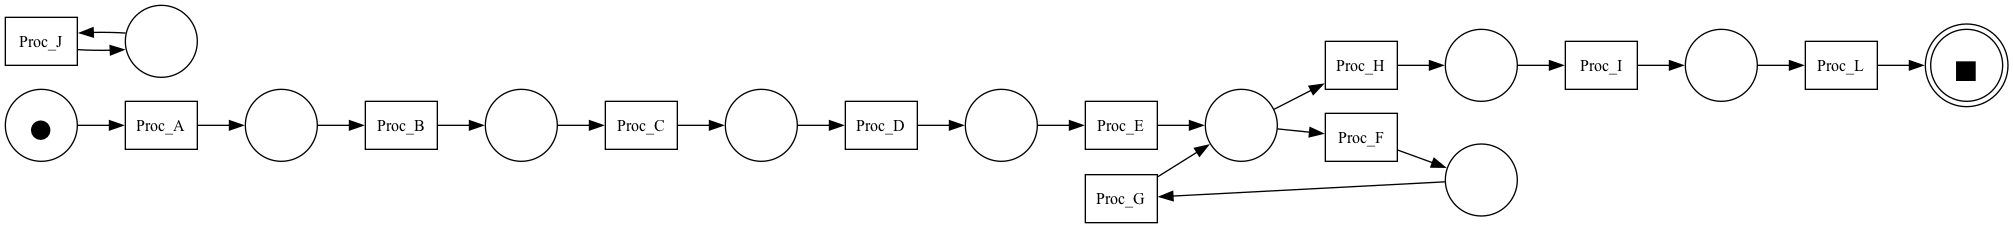

Relations:
 causal
	artificial_start
		{'Proc_A'}
	Proc_A
		{'Proc_B'}
	Proc_B
		{'Proc_C'}
	Proc_C
		{'Proc_D'}
	Proc_D
		{'Proc_E'}
	Proc_E
		{'Proc_F'}
	Proc_F
		{'Proc_G'}
	Proc_G
		{'Proc_F', 'Proc_H'}
	Proc_H
		{'Proc_I'}
	Proc_I
		{'Proc_L'}
	Proc_L
		{'artificial_end'}
parallel
follows
	artificial_start
		{'Proc_A'}
	Proc_A
		{'Proc_B'}
	Proc_B
		{'Proc_C'}
	Proc_C
		{'Proc_D'}
	Proc_D
		{'Proc_E'}
	Proc_E
		{'Proc_F'}
	Proc_F
		{'Proc_G'}
	Proc_G
		{'Proc_F', 'Proc_H'}
	Proc_H
		{'Proc_I'}
	Proc_I
		{'Proc_L'}
	Proc_L
		{'artificial_end'}
square
	Proc_F
		{'Proc_G'}
	Proc_G
		{'Proc_F'}
triangle
	Proc_F
		{'Proc_G'}
	Proc_G
		{'Proc_F'}

Length One Loop Inputs:
 Proc_J
	{'Proc_B'}

Length One Loop Outputs:
 Proc_J
	{'Proc_C'}

Footprint Matrices to aggregate:



,artificial_start,artificial_end,Proc_A,Proc_B,Proc_C,Proc_D,Proc_E,Proc_F,Proc_G,Proc_H,Proc_I,Proc_K,Proc_L,Proc_M,Proc_N
artificial_start,#,#,->,#,#,#,#,#,#,#,#,#,#,#,#
artificial_end,#,#,#,#,#,#,#,#,#,#,#,#,<-,#,#
Proc_A,<-,#,#,->,#,#,#,#,#,#,#,#,#,#,#
Proc_B,#,#,<-,#,->,#,#,#,#,#,#,#,#,#,#
Proc_C,#,#,#,<-,#,->,#,#,#,#,#,#,#,#,#
Proc_D,#,#,#,#,<-,#,#,#,#,#,#,#,#,->,#
Proc_E,#,#,#,#,#,#,#,->,#,#,#,#,#,#,<-
Proc_F,#,#,#,#,#,#,<-,#,->,#,#,#,#,#,#
Proc_G,#,#,#,#,#,#,#,<-,#,->,#,#,#,#,#
Proc_H,#,#,#,#,#,#,#,#,<-,#,#,->,#,#,#


,artificial_start,artificial_end,Proc_A,Proc_B,Proc_C,Proc_D,Proc_E,Proc_F,Proc_G,Proc_H,Proc_I,Proc_K,Proc_L,Proc_M,Proc_N
artificial_start,#,#,->,#,#,#,#,#,#,#,#,#,#,#,#
artificial_end,#,#,#,#,#,#,#,#,#,#,#,#,<-,#,#
Proc_A,<-,#,#,->,#,#,#,#,#,#,#,#,#,#,#
Proc_B,#,#,<-,#,->,#,#,#,#,#,#,#,#,#,#
Proc_C,#,#,#,<-,#,->,#,#,#,#,#,#,#,#,#
Proc_D,#,#,#,#,<-,#,->,#,#,#,#,#,#,->,#
Proc_E,#,#,#,#,#,<-,#,->,#,#,#,#,#,#,<-
Proc_F,#,#,#,#,#,#,<-,#,S,#,#,#,#,#,#
Proc_G,#,#,#,#,#,#,#,S,#,->,#,#,#,#,#
Proc_H,#,#,#,#,#,#,#,#,<-,#,->,#,#,#,#


,artificial_start,artificial_end,Proc_A,Proc_B,Proc_C,Proc_D,Proc_E,Proc_F,Proc_G,Proc_H,Proc_I,Proc_K,Proc_L,Proc_M,Proc_N
artificial_start,#,#,->,#,#,#,#,#,#,#,#,#,#,#,#
artificial_end,#,#,#,#,#,#,#,#,#,#,#,#,<-,#,#
Proc_A,<-,#,#,->,#,#,#,#,#,#,#,#,#,#,#
Proc_B,#,#,<-,#,->,#,#,#,#,#,#,#,#,#,#
Proc_C,#,#,#,<-,#,->,#,#,#,#,#,#,#,#,#
Proc_D,#,#,#,#,<-,#,->,#,#,#,#,#,#,#,#
Proc_E,#,#,#,#,#,<-,#,->,#,#,#,#,#,#,#
Proc_F,#,#,#,#,#,#,<-,#,S,#,#,#,#,#,#
Proc_G,#,#,#,#,#,#,#,S,#,->,#,#,#,#,#
Proc_H,#,#,#,#,#,#,#,#,<-,#,->,#,#,#,#




1-length-loop free net soundness: True


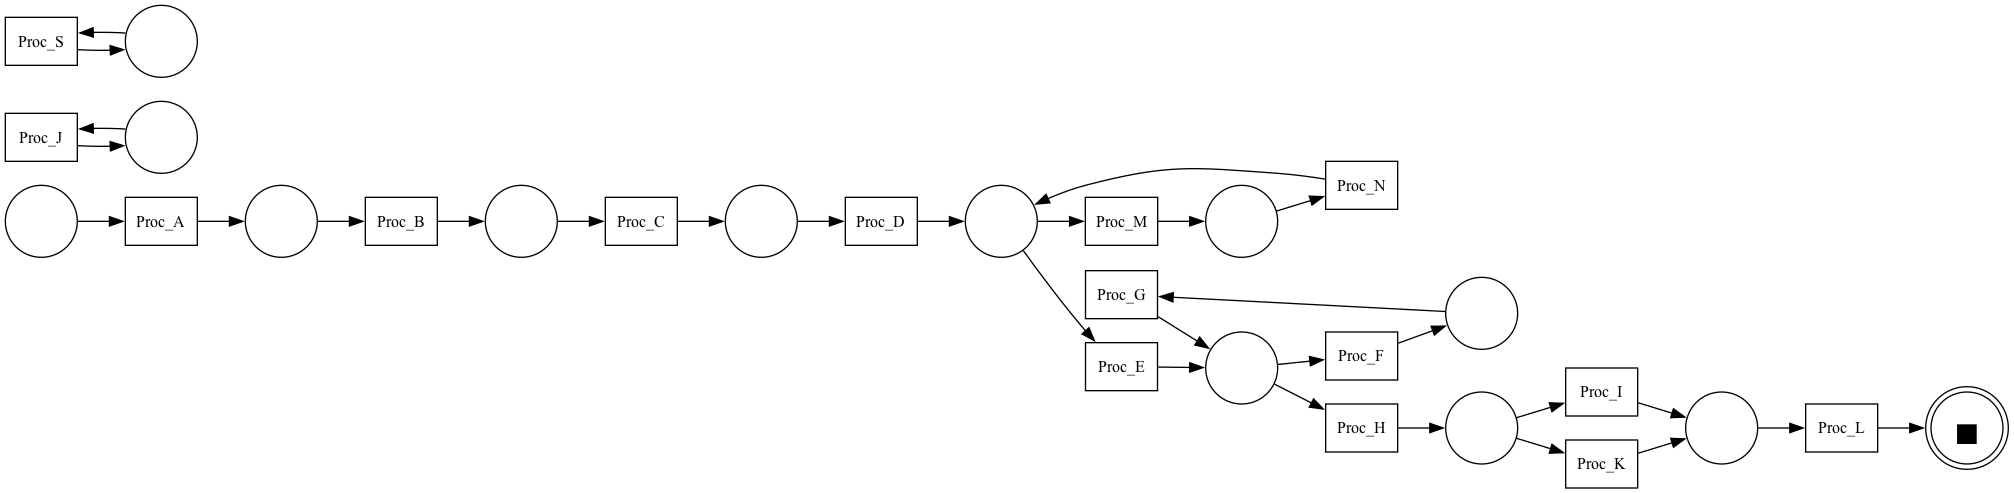

In [11]:
FTs_vitro, oneL_inputs_dic_vitro, oneL_outputs_dic_vitro, loop_one_list_vitro = simulate_nodes_computation(el_splits=el_splits_vitro)
sum_FT_vitro, events_vitro = pm4py.algo.discovery.alpha.variants.plus.aggregate_fms(fts=FTs_vitro)
net_vitro, initial_marking_vitro, final_marking_vitro = apply_aggr(fm=sum_FT_vitro,
                                                                   events=events_vitro,
                                                                   oneL_inputs=oneL_inputs_dic_vitro,
                                                                   oneL_outputs=oneL_outputs_dic_vitro,
                                                                   loop_one_list=loop_one_list_vitro
                                                                   )
assert sum_FT_vitro.equals(footprint_matrix_tot_vitro)
pm4py.view_petri_net(net_vitro, initial_marking_vitro, final_marking_vitro)